In [1]:
folder_of_data = "/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/"

In [2]:
!pip3 install matplotlib
!pip3 install pandas
!pip3 install h5py
!pip3 install scipy numba cython multiprocess boost==1.74
# !pip3 install coniii


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement boost==1.74 (from versions: 0.1)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for boost==1.74


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os

In [4]:
def find_file_recursive(root_folder, file_name, current_depth=0, max_depth=None, verbose=True):
    """
    Recursively search for a file in all subdirectories
    
    Args:
        root_folder (str): Path to start searching from
        file_name (str): Name of the file to look for
        current_depth (int): Current recursion depth (for display purposes)
        max_depth (int): Maximum depth to search (None for unlimited)
        verbose (bool): Whether to print detailed output
    
    Returns:
        list: List of paths where the file was found
    """
    found_paths = []
    indent = "  " * current_depth
    
    # Check if we've reached max depth
    if max_depth is not None and current_depth > max_depth:
        return found_paths
    
    # Normalize the path to handle different path separators
    root_folder = os.path.normpath(root_folder)
    
    # Check if the folder exists and is accessible
    if not os.path.exists(root_folder):
        if verbose:
            print(f"{indent}❌ Folder does not exist: {root_folder}")
        return found_paths
    
    if not os.path.isdir(root_folder):
        if verbose:
            print(f"{indent}❌ Not a directory: {root_folder}")
        return found_paths
    
    try:
        items = os.listdir(root_folder)
    except PermissionError:
        if verbose:
            print(f"{indent}❌ Permission denied: {root_folder}")
        return found_paths
    except Exception as e:
        if verbose:
            print(f"{indent}❌ Error accessing {root_folder}: {e}")
        return found_paths
    
    if verbose:
        print(f"{indent}📁 Searching in: {root_folder}")
    
    # Check if the file exists in current directory
    file_path = os.path.join(root_folder, file_name)
    if os.path.isfile(file_path):  # Use isfile instead of exists to ensure it's a file
        if verbose:
            print(f"{indent}  ✅ Found '{file_name}'")
        found_paths.append(file_path)
    else:
        if verbose:
            print(f"{indent}  ❌ '{file_name}' not found")
    
    # Recursively search in subdirectories
    subdirs = []
    for item in items:
        item_path = os.path.join(root_folder, item)
        if os.path.isdir(item_path):
            subdirs.append(item_path)
    
    if verbose and subdirs:
        print(f"{indent}  📂 Found {len(subdirs)} subdirectories")
    
    for subdir in subdirs:
        try:
            subfolder_results = find_file_recursive(subdir, file_name, current_depth + 1, max_depth, verbose)
            found_paths.extend(subfolder_results)
        except Exception as e:
            if verbose:
                print(f"{indent}  ❌ Error processing {subdir}: {e}")
    
    return found_paths

In [5]:
def extract_results_folder(file_path):
    """
    Extract the folder name that ends with '_results' from a file path
    
    Args:
        file_path (str): Full path to a file
        
    Returns:
        str: The folder name ending with '_results', or None if not found
    """
    # Split the path into components
    path_parts = file_path.split(os.sep)
    
    # Look for a folder that ends with '_results'
    for part in path_parts:
        if part.endswith('_results'):
            return part
    
    return None

In [6]:
def ensure_directory_exists(directory_path):
    """
    Check if a directory exists and create it (including all parent directories) if it doesn't.
    
    Args:
        directory_path (str): Path to the directory to check/create
    
    Returns:
        bool: True if directory exists or was created successfully, False if creation failed
    """
    try:
        os.makedirs(directory_path, exist_ok=True)
        return True
    except Exception as e:
        print(f"Error creating directory '{directory_path}': {e}")
        return False

In [7]:
# review files of path saved in folder_of_data variables
# not all mice have full data, still working on incomplete mice
# This will help you select which csv in the path to use
all_reach_states = find_file_recursive(folder_of_data, "per_reach_state.csv")

📁 Searching in: /data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many
  ❌ 'per_reach_state.csv' not found
  📂 Found 21 subdirectories
  📁 Searching in: /data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210421_results
    ❌ 'per_reach_state.csv' not found
    📂 Found 10 subdirectories
    📁 Searching in: /data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210421_results/210421_rep2
      ❌ 'per_reach_state.csv' not found
      📂 Found 4 subdirectories
      📁 Searching in: /data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210421_results/210421_rep2/begin_reach
        ✅ Found 'per_reach_state.csv'
      📁 Searching in: /data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210421_results/210421_rep2/mid_reach
        ✅ Found 'per_reach_state.csv'
      📁 Searching in: /data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pse

In [8]:
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Union
def calculate_session_averages(df: pd.DataFrame, confidence: float = 0.8) -> Dict:
    """
    Calculate average statistics across all reaches in a session for kinematic 
    and neural data from a dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: reach_idx, stim, x, y, z, firing_rate, energy, j, h
        Each row represents a single time point for a specific reach in a specific stimulus
    confidence : float, optional
        Confidence level for intervals (default=0.8)
        
    Returns:
    --------
    dict
        Dictionary containing:
        - 'by_stimulus': Dict with stats for each stimulus condition
            - Each stimulus contains: x, y, z, firing_rate, energy, j, h
            - Each variable has: mean (over time), lower_ci, upper_ci, time_series_mean, 
              time_series_lower, time_series_upper
        - 'overall': Dict with overall session averages across all stimuli
        - 'metadata': Dict with session information (n_reaches, n_stimuli, n_timepoints)
    """
    
    def mean_confidence_interval(data: np.ndarray, confidence: float = 0.8):
        """Calculate mean and confidence interval for data."""
        import scipy.stats as stats
        
        n = len(data)
        if n == 0:
            return np.nan, np.nan, np.nan
        if n == 1:
            return data[0], data[0], data[0]
        
        mean = np.mean(data)
        se = stats.sem(data)
        h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
        
        return mean, mean - h, mean + h
    
    # Get unique stimuli
    stimuli = sorted(df['stim'].unique())
    
    # First, calculate 3D velocity for each reach
    df = df.copy()  # Don't modify original
    velocity_data = []
    
    for (reach_idx, stim), group in df.groupby(['reach_idx', 'stim']):
        group = group.sort_values('time_idx') if 'time_idx' in group.columns else group
        
        x_vals = group['x'].values
        y_vals = group['y'].values
        z_vals = group['z'].values
        
        # Calculate velocity as magnitude of position change (assuming dt=1)
        dx = np.diff(x_vals, prepend=x_vals[0])
        dy = np.diff(y_vals, prepend=y_vals[0])
        dz = np.diff(z_vals, prepend=z_vals[0])
        
        velocity = np.sqrt(dx**2 + dy**2 + dz**2)
        
        for i, vel in enumerate(velocity):
            velocity_data.append({
                'reach_idx': reach_idx,
                'stim': stim,
                'velocity_3d': vel
            })
    
    # Merge velocity back into dataframe
    velocity_df = pd.DataFrame(velocity_data)
    df = df.reset_index(drop=True)
    df['velocity_3d'] = velocity_df['velocity_3d'].values
    
    # Variables to process (now including velocity_3d)
    variables = ['x', 'y', 'z', 'velocity_3d', 'firing_rate', 'energy', 'j', 'h']
    
    # Initialize results
    results = {
        'by_stimulus': {},
        'overall': {},
        'metadata': {
            'n_stimuli': len(stimuli),
            'n_reaches_total': df['reach_idx'].nunique(),
            'confidence_level': confidence
        }
    }
    
    # Collect all data for overall averages
    all_data = {var: [] for var in variables}
    
    # Calculate statistics for each stimulus condition
    for stim in stimuli:
        stim_data = df[df['stim'] == stim].copy()
        
        # Add time index within each reach
        stim_data['time_idx'] = stim_data.groupby('reach_idx').cumcount()
        max_time = stim_data['time_idx'].max() + 1
        
        n_reaches = stim_data['reach_idx'].nunique()
        
        # Initialize storage for this stimulus
        stim_results = {
            'n_reaches': n_reaches,
            'n_timepoints': max_time
        }
        
        for var in variables:
            if var not in stim_data.columns:
                continue
                
            # Time series statistics (mean across reaches at each time point)
            time_series = {'mean': [], 'lower': [], 'upper': []}
            
            for t in range(max_time):
                time_slice = stim_data[stim_data['time_idx'] == t]
                if len(time_slice) > 0:
                    values = time_slice[var].values
                    m, l, u = mean_confidence_interval(values, confidence)
                    time_series['mean'].append(m)
                    time_series['lower'].append(l)
                    time_series['upper'].append(u)
                    
                    # Collect for overall averages
                    all_data[var].extend(values)
            
            # Convert to numpy arrays
            time_series['mean'] = np.array(time_series['mean'])
            time_series['lower'] = np.array(time_series['lower'])
            time_series['upper'] = np.array(time_series['upper'])
            
            # Calculate scalar summary statistics
            all_values = stim_data[var].values
            overall_mean, overall_lower, overall_upper = mean_confidence_interval(all_values, confidence)
            
            stim_results[var] = {
                # Scalar summaries
                'mean': overall_mean,
                'lower_ci': overall_lower,
                'upper_ci': overall_upper,
                'std': np.std(all_values),
                'min': np.min(all_values),
                'max': np.max(all_values),
                # Time series
                'time_series_mean': time_series['mean'],
                'time_series_lower': time_series['lower'],
                'time_series_upper': time_series['upper']
            }
        
        results['by_stimulus'][stim] = stim_results
    
    # Calculate overall session averages (across all stimuli)
    for var in variables:
        if all_data[var]:
            values = np.array(all_data[var])
            overall_mean, overall_lower, overall_upper = mean_confidence_interval(values, confidence)
            
            results['overall'][var] = {
                'mean': overall_mean,
                'lower_ci': overall_lower,
                'upper_ci': overall_upper,
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values)
            }
    
    return results


def calculate_reach_averages(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the average value of each variable for each reach, including 3D velocity.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: reach_idx, stim, x, y, z, firing_rate, energy, j, h
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with one row per reach, containing average values for each variable
        including velocity_3d
    """
    df = df.copy()
    
    # Calculate 3D velocity for each reach
    reach_velocities = []
    
    for (reach_idx, stim), group in df.groupby(['reach_idx', 'stim']):
        x_vals = group['x'].values
        y_vals = group['y'].values
        z_vals = group['z'].values
        
        # Calculate velocity as magnitude of position change
        dx = np.diff(x_vals, prepend=x_vals[0])
        dy = np.diff(y_vals, prepend=y_vals[0])
        dz = np.diff(z_vals, prepend=z_vals[0])
        
        velocity = np.sqrt(dx**2 + dy**2 + dz**2)
        avg_velocity = np.mean(velocity)
        
        reach_velocities.append({
            'reach_idx': reach_idx,
            'stim': stim,
            'velocity_3d': avg_velocity
        })
    
    variables = ['x', 'y', 'z', 'firing_rate', 'energy', 'j', 'h']
    available_vars = [v for v in variables if v in df.columns]
    
    # Group by reach and stimulus, calculate mean of each variable
    reach_averages = df.groupby(['reach_idx', 'stim'])[available_vars].mean().reset_index()
    
    # Merge velocity data
    velocity_df = pd.DataFrame(reach_velocities)
    reach_averages = reach_averages.merge(velocity_df, on=['reach_idx', 'stim'])
    
    return reach_averages


def get_session_summary(df: pd.DataFrame, confidence: float = 0.8) -> pd.DataFrame:
    """
    Get a summary DataFrame of session averages by stimulus.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: reach_idx, stim, x, y, z, firing_rate, energy, j, h
    confidence : float, optional
        Confidence level for intervals (default=0.8)
        
    Returns:
    --------
    pd.DataFrame
        Summary DataFrame with stimulus as index and variable statistics as columns
    """
    stats = calculate_session_averages(df, confidence)
    
    # Build summary table
    summary_rows = []
    
    for stim, stim_data in stats['by_stimulus'].items():
        row = {'stimulus': stim, 'n_reaches': stim_data['n_reaches']}
        
        for var in ['x', 'y', 'z', 'velocity_3d', 'firing_rate', 'energy', 'j', 'h']:
            if var in stim_data:
                row[f'{var}_mean'] = stim_data[var]['mean']
                row[f'{var}_std'] = stim_data[var]['std']
                row[f'{var}_lower_ci'] = stim_data[var]['lower_ci']
                row[f'{var}_upper_ci'] = stim_data[var]['upper_ci']
        
        summary_rows.append(row)
    
    # Add overall row
    overall_row = {'stimulus': 'OVERALL', 'n_reaches': stats['metadata']['n_reaches_total']}
    for var in ['x', 'y', 'z', 'velocity_3d', 'firing_rate', 'energy', 'j', 'h']:
        if var in stats['overall']:
            overall_row[f'{var}_mean'] = stats['overall'][var]['mean']
            overall_row[f'{var}_std'] = stats['overall'][var]['std']
            overall_row[f'{var}_lower_ci'] = stats['overall'][var]['lower_ci']
            overall_row[f'{var}_upper_ci'] = stats['overall'][var]['upper_ci']
    
    summary_rows.append(overall_row)
    
    return pd.DataFrame(summary_rows)

In [9]:
print("Columns: ")
import numpy as np
print("- "+"\n- ".join(pd.read_csv(all_reach_states[0]).columns))
print(all_reach_states[5])
reach = pd.read_csv(all_reach_states[3])

reach[np.logical_and(reach['reach_idx'] == 0, reach['stim'] == 0)]

Columns: 
- reach_idx
- stim
- x
- y
- z
- firing_rate
- energy
- j
- h
/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210421_results/210421_rep1/mid_reach/per_reach_state.csv


,reach_idx,stim,x,y,z,firing_rate,energy,j,h
0,0,0,0.017835,0.032775,0.971543,0.500000,-3.185109,0.036826,3.148283
1,0,0,0.017866,0.032775,0.971573,0.523810,-2.441660,0.151698,2.289962
2,0,0,0.017898,0.032811,0.971634,0.500000,-2.012761,0.238483,1.774278
3,0,0,0.017893,0.032835,0.971554,0.511111,-2.991237,0.487923,2.503313
4,0,0,0.017811,0.032799,0.971147,0.506667,-1.738389,0.013711,1.724678
...,...,...,...,...,...,...,...,...,...
695,0,0,0.025657,0.021973,0.650744,0.586667,-2.701706,0.373427,2.328279
696,0,0,0.025430,0.022038,0.650484,0.570370,-1.353516,-0.065996,1.419512
697,0,0,0.025271,0.022093,0.650191,0.583333,-3.016582,0.220237,2.796345
698,0,0,0.025204,0.022140,0.649952,0.552381,-3.332827,0.712626,2.620201


In [13]:
import os
import multiprocessing as mp
matlab_file = "/data001/projects/enserrog/AbigailData/energy_over_time/"

# pool = mp.Pool(processes=8)

# def _generate_results_of_session(session):
#     if not "full_reach" in session:
#         return
        
#     print(session)
#     session_id = session.split('_results')[0][-6:]
#     print(f"Session_id: {session_id}")
    
#     df = pd.read_csv(session)
    
#     # Calculate statistics
#     stats = calculate_statistics_from_dataframe(df, confidence=0.8, output_dir=f'./stats_output_4/{session_id}')
    
#     # Plot the results
#     plot_all_overlayed(stats, critical_energy=0.5, output_dir=f'./plots_output_4/{session_id}')

session_data = {}

for session in all_reach_states:
    
    if (not "full_reach" in session) or (not "rep1" in session or "rep10" in session):
            continue
    
    print(session)
    session_id = session.split('_results')[0][-6:]
    print(f"Session_id: {session_id}")

    df = pd.read_csv(session)

    session_data[session_id] = df
    
    

# pool.map(_generate_results_of_session, all_reach_states)

/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210421_results/210421_rep1/full_reach/per_reach_state.csv
Session_id: 210421
/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210422_results/210422_rep1/full_reach/per_reach_state.csv
Session_id: 210422
/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210423_results/210423_rep1/full_reach/per_reach_state.csv
Session_id: 210423
/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210425_results/210425_rep1/full_reach/per_reach_state.csv
Session_id: 210425
/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210511_results/210511_rep1/full_reach/per_reach_state.csv
Session_id: 210511
/data001/projects/enserrog/AbigailData/energy_over_time/energy_decomp_Pseudo_many/210512_results/210512_rep1/full_reach/per_reach_state.csv
Session_id: 210512
/data001/projects/enserrog/AbigailData/energy_

In [14]:
# Helper function to find extrema within a constrained range
def find_extrema_in_range(data, start_idx, end_idx):
    """Find min and max indices within the specified range."""
    # Ensure indices are within bounds
    start_idx = max(0, start_idx)
    end_idx = min(len(data), end_idx)
    
    if start_idx >= end_idx or start_idx >= len(data):
        # Fallback to global if range is invalid
        return np.argmin(data), np.argmax(data)
    
    # Get the slice and find extrema
    data_slice = data[start_idx:end_idx]
    local_min_idx = np.argmin(data_slice)
    local_max_idx = np.argmax(data_slice)
    
    # Convert back to global indices
    global_min_idx = start_idx + local_min_idx
    global_max_idx = start_idx + local_max_idx
    
    return global_min_idx, global_max_idx

In [15]:
session_data.keys()

dict_keys(['210421', '210422', '210423', '210425', '210511', '210512', '210514', '210515', '210606', '210608', '210614', '210619', '210620', '210622', '210623', '220515', '220516', '220517', '220518', '220519', '220520'])

In [19]:
from multiprocessing import Pool
import numpy as np

def process_session(args):
    stim, session, data, window = args
    
    stats = calculate_session_averages(data, confidence=0.8)
    
    data_frame = {
        'velocity':      find_extrema_in_range(stats['by_stimulus'][stim]['velocity_3d']['time_series_mean'], window[0], window[1]),
        'firing_rate':   find_extrema_in_range(stats['by_stimulus'][stim]['firing_rate']['time_series_mean'],  window[0], window[1]),
        'energy':        find_extrema_in_range(stats['by_stimulus'][stim]['energy']['time_series_mean'],        window[0], window[1]),
        'Boltzman_prob': find_extrema_in_range(np.exp(-stats['by_stimulus'][stim]['energy']['time_series_mean']), window[0], window[1]),
        'original_data': data
    }
    
    print(f"✓ Done: stim={stim}, session={session}")
    return stim, session, data_frame

# Build all (stim, session) task arguments
window = [375, 425]
tasks = [
    (stim, session, session_data[session], window)
    for stim in range(0, 3)
    for session in session_data.keys()
]

stim_sessions_extrema = {}
with Pool() as pool:
    for stim, session, data_frame in pool.imap_unordered(process_session, tasks):
        print(f"← Received: stim={stim}, session={session}")
        stim_sessions_extrema.setdefault(stim, {})[session] = data_frame

print("All done!")

✓ Done: stim=0, session=210422
← Received: stim=0, session=210422
✓ Done: stim=0, session=210421
← Received: stim=0, session=210421
✓ Done: stim=0, session=220516
← Received: stim=0, session=220516
✓ Done: stim=1, session=210623✓ Done: stim=0, session=210614

← Received: stim=1, session=210623
← Received: stim=0, session=210614
✓ Done: stim=2, session=210423
← Received: stim=2, session=210423
✓ Done: stim=0, session=220519
✓ Done: stim=1, session=210614
← Received: stim=0, session=220519
← Received: stim=1, session=210614
✓ Done: stim=1, session=220515
✓ Done: stim=1, session=210423← Received: stim=1, session=220515

← Received: stim=1, session=210423
✓ Done: stim=0, session=220517
← Received: stim=0, session=220517
✓ Done: stim=1, session=210620
← Received: stim=1, session=210620
✓ Done: stim=0, session=210623
← Received: stim=0, session=210623
✓ Done: stim=2, session=210608
← Received: stim=2, session=210608
✓ Done: stim=0, session=210608
← Received: stim=0, session=210608
✓ Done: st

In [20]:
stim_sessions_extrema[0]['210423']['original_data'].columns

Index(['reach_idx', 'stim', 'x', 'y', 'z', 'firing_rate', 'energy', 'j', 'h'], dtype='object')

In [21]:

for stim in range(0,3):
    closest_list = []
    closest_point = [0, 0, 0, 0]
    for session in stim_sessions_extrema[stim].keys():
        max_velocity_idx = stim_sessions_extrema[stim][session]['velocity'][1]

        close_set = [
            np.abs(max_velocity_idx - stim_sessions_extrema[stim][session]['energy'][0]),
            np.abs(max_velocity_idx - stim_sessions_extrema[stim][session]['energy'][1]),
            np.abs(max_velocity_idx - stim_sessions_extrema[stim][session]['firing_rate'][0]),
            np.abs(max_velocity_idx - stim_sessions_extrema[stim][session]['firing_rate'][1])
        ]
        
        idx_closest = np.argmin(
            close_set
        )

        closest_list += [close_set]
        
        closest_point[idx_closest] += 1
    print(closest_point)
    print(np.array(closest_list))
    

[8, 5, 5, 3]
[[22 14 12 25]
 [20 22  1 21]
 [17 17 13 16]
 [18  9 17 29]
 [ 7  7  8  8]
 [ 7  7 27  8]
 [13 25 21 14]
 [ 1  4 18  2]
 [23 13 14 26]
 [ 6  6 23  8]
 [ 8 18 23 16]
 [15 27 30 19]
 [17  3  1 21]
 [ 5 21 25 24]
 [ 1 29 28  0]
 [14  2  2 24]
 [25  2  1 19]
 [20  6 17 27]
 [19 15 20 20]
 [12 22 17  8]
 [ 5 25 27  0]]
[6, 4, 5, 6]
[[ 4 20 11  3]
 [27 13 15 31]
 [ 5  7 33  4]
 [24  7 25 10]
 [ 9 18 19  5]
 [24  4  0 25]
 [10 29 21 11]
 [ 2 11 15 25]
 [13  8 14 21]
 [22  9 12 25]
 [ 4 32 32  1]
 [17  4  2 25]
 [25 11 14  3]
 [19 19 23 21]
 [27 17 14 29]
 [21 11  8 13]
 [15 17 24 16]
 [ 4 21 24  8]
 [11 23  2 13]
 [ 5 19 10 13]
 [13 12 14 10]]
[7, 5, 6, 3]
[[27  1 20  3]
 [21 12 15  7]
 [22  7  2 23]
 [ 4 26 28 18]
 [13 17 24 13]
 [ 5 21  4 14]
 [ 5 27 30 11]
 [10 22 28 15]
 [28  3  3  9]
 [ 2 11 17  4]
 [ 3 23 25 15]
 [20  1  1 22]
 [22 19 21 22]
 [10 13 30  8]
 [12 13 24 10]
 [27 16 13 31]
 [19  5 15 24]
 [ 9 19  1 22]
 [ 7 13  5  9]
 [ 6 18 17 10]
 [31 12  7  7]]


# Data Review:

For stim_0 it comes off that min firing rate is closer to max velocity, looking closer max energy tends to be just a few time stamps off min firing rate

In stim_1 Min energy is closest for most session to max velocity, When min energy is the closest max firing rate is close as well but off by a few time stamps. When it is max energy is closer then min firing rate is not to far from it. 

# Discussion:
We are seeing the covariance again with min energy aligning with max firing rate and max firing rate aligning with min energy.   

# Generalizable Arbitration

In [17]:
from itertools import combinations
def arbitration_test(stim_sessions_extrema: Dict, 
                     stim_sessions_data: Optional[Dict] = None,
                     verbose: bool = True) -> Dict:
    """
    Perform arbitration test to determine whether energy or firing rate better predicts
    velocity extrema timing across sessions.
    
    Test 1: For each session, compare its max velocity index to energy/firing_rate extrema
            from OTHER sessions. If energy from other sessions is closer, energy is more
            generalizable. If firing rate from other sessions is closer, firing rate is
            more generalizable.
    
    Test 2: Within-session comparison (original test) - which measure is closest to 
            max velocity within the same session.
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                    'boltzmann': (min_idx, max_idx)  # optional
                }
            }
        }
    stim_sessions_data : Dict, optional
        Full time series data for more detailed analysis
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing:
        - 'within_session': Results of within-session comparisons
        - 'cross_session': Results of cross-session (swap) comparisons
        - 'summary': Overall summary statistics
    """
    
    results = {
        'within_session': {},
        'cross_session': {},
        'summary': {}
    }
    
    # =========================================================================
    # TEST 1: WITHIN-SESSION COMPARISON (Original test)
    # For each session, which of its own measures is closest to max velocity?
    # =========================================================================
    
    if verbose:
        print("=" * 70)
        print("TEST 1: WITHIN-SESSION COMPARISON")
        print("Which measure's extrema is closest to max velocity within same session?")
        print("=" * 70)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        
        # Counts: [energy_min, energy_max, firing_rate_min, firing_rate_max]
        closest_counts = [0, 0, 0, 0]
        all_distances = []
        session_details = {}
        
        for session in sessions.keys():
            max_velocity_idx = sessions[session]['velocity'][1]
            
            distances = [
                np.abs(max_velocity_idx - sessions[session]['energy'][0]),      # energy min
                np.abs(max_velocity_idx - sessions[session]['energy'][1]),      # energy max
                np.abs(max_velocity_idx - sessions[session]['firing_rate'][0]), # firing_rate min
                np.abs(max_velocity_idx - sessions[session]['firing_rate'][1])  # firing_rate max
            ]
            
            idx_closest = np.argmin(distances)
            closest_counts[idx_closest] += 1
            all_distances.append(distances)
            
            session_details[session] = {
                'max_velocity_idx': max_velocity_idx,
                'distances': distances,
                'closest': ['energy_min', 'energy_max', 'firing_min', 'firing_max'][idx_closest],
                'closest_distance': distances[idx_closest]
            }
        
        results['within_session'][stim] = {
            'closest_counts': closest_counts,
            'labels': ['energy_min', 'energy_max', 'firing_min', 'firing_max'],
            'all_distances': np.array(all_distances),
            'session_details': session_details,
            'energy_wins': closest_counts[0] + closest_counts[1],
            'firing_wins': closest_counts[2] + closest_counts[3]
        }
        
        if verbose:
            print(f"\nStimulus {stim}:")
            print(f"  Closest counts [energy_min, energy_max, firing_min, firing_max]: {closest_counts}")
            print(f"  Energy wins: {closest_counts[0] + closest_counts[1]}, "
                  f"Firing Rate wins: {closest_counts[2] + closest_counts[3]}")
            print(f"  Mean distances: {np.mean(all_distances, axis=0).round(2)}")
    
    # =========================================================================
    # TEST 2: CROSS-SESSION SWAP TEST
    # For each session, compare its max velocity to OTHER sessions' extrema
    # This tests generalizability - which measure transfers better across sessions
    # =========================================================================
    
    if verbose:
        print("\n" + "=" * 70)
        print("TEST 2: CROSS-SESSION SWAP TEST")
        print("Compare each session's max velocity to OTHER sessions' extrema")
        print("Tests which measure generalizes better across sessions")
        print("=" * 70)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        if n_sessions < 2:
            if verbose:
                print(f"\nStimulus {stim}: Not enough sessions for cross-session test")
            continue
        
        # For each session, compare to all other sessions
        cross_session_results = []
        energy_closer_count = 0
        firing_closer_count = 0
        
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]
            
            # Compare to each other session's extrema
            for source_session in session_list:
                if source_session == target_session:
                    continue
                
                # Get source session's extrema
                source_energy_min = sessions[source_session]['energy'][0]
                source_energy_max = sessions[source_session]['energy'][1]
                source_firing_min = sessions[source_session]['firing_rate'][0]
                source_firing_max = sessions[source_session]['firing_rate'][1]
                
                # Calculate distances from target's max velocity to source's extrema
                energy_distances = [
                    np.abs(target_max_vel - source_energy_min),
                    np.abs(target_max_vel - source_energy_max)
                ]
                firing_distances = [
                    np.abs(target_max_vel - source_firing_min),
                    np.abs(target_max_vel - source_firing_max)
                ]
                
                # Best (minimum) distance for each measure
                best_energy_dist = min(energy_distances)
                best_firing_dist = min(firing_distances)
                
                if best_energy_dist < best_firing_dist:
                    energy_closer_count += 1
                    winner = 'energy'
                elif best_firing_dist < best_energy_dist:
                    firing_closer_count += 1
                    winner = 'firing_rate'
                else:
                    winner = 'tie'
                
                cross_session_results.append({
                    'target_session': target_session,
                    'source_session': source_session,
                    'target_max_vel_idx': target_max_vel,
                    'best_energy_distance': best_energy_dist,
                    'best_firing_distance': best_firing_dist,
                    'winner': winner
                })
        
        results['cross_session'][stim] = {
            'comparisons': cross_session_results,
            'energy_closer_count': energy_closer_count,
            'firing_closer_count': firing_closer_count,
            'total_comparisons': len(cross_session_results)
        }
        
        if verbose:
            print(f"\nStimulus {stim}:")
            print(f"  Total cross-session comparisons: {len(cross_session_results)}")
            print(f"  Energy extrema closer: {energy_closer_count} "
                  f"({100*energy_closer_count/len(cross_session_results):.1f}%)")
            print(f"  Firing rate extrema closer: {firing_closer_count} "
                  f"({100*firing_closer_count/len(cross_session_results):.1f}%)")
    
    # =========================================================================
    # TEST 3: DETAILED SWAP ANALYSIS
    # Swap specific sessions' firing rates with others and measure prediction error
    # =========================================================================
    
    if verbose:
        print("\n" + "=" * 70)
        print("TEST 3: PAIRWISE SESSION SWAP ANALYSIS")
        print("For each pair of sessions, if we used Session A's extrema to predict")
        print("Session B's max velocity timing, how well does each measure do?")
        print("=" * 70)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        
        if len(session_list) < 2:
            continue
        
        swap_analysis = []
        
        # For each pair of sessions
        for sess_a, sess_b in combinations(session_list, 2):
            # Predict B's max velocity using A's extrema
            b_max_vel = sessions[sess_b]['velocity'][1]
            
            # Using A's energy extrema
            a_energy_prediction_error = min(
                np.abs(b_max_vel - sessions[sess_a]['energy'][0]),
                np.abs(b_max_vel - sessions[sess_a]['energy'][1])
            )
            
            # Using A's firing rate extrema
            a_firing_prediction_error = min(
                np.abs(b_max_vel - sessions[sess_a]['firing_rate'][0]),
                np.abs(b_max_vel - sessions[sess_a]['firing_rate'][1])
            )
            
            # And vice versa - predict A's max velocity using B's extrema
            a_max_vel = sessions[sess_a]['velocity'][1]
            
            b_energy_prediction_error = min(
                np.abs(a_max_vel - sessions[sess_b]['energy'][0]),
                np.abs(a_max_vel - sessions[sess_b]['energy'][1])
            )
            
            b_firing_prediction_error = min(
                np.abs(a_max_vel - sessions[sess_b]['firing_rate'][0]),
                np.abs(a_max_vel - sessions[sess_b]['firing_rate'][1])
            )
            
            swap_analysis.append({
                'session_pair': (sess_a, sess_b),
                'a_predicts_b_energy_error': a_energy_prediction_error,
                'a_predicts_b_firing_error': a_firing_prediction_error,
                'b_predicts_a_energy_error': b_energy_prediction_error,
                'b_predicts_a_firing_error': b_firing_prediction_error,
                'avg_energy_error': (a_energy_prediction_error + b_energy_prediction_error) / 2,
                'avg_firing_error': (a_firing_prediction_error + b_firing_prediction_error) / 2
            })
        
        if swap_analysis:
            avg_energy_errors = [s['avg_energy_error'] for s in swap_analysis]
            avg_firing_errors = [s['avg_firing_error'] for s in swap_analysis]
            
            results['cross_session'][stim]['swap_analysis'] = swap_analysis
            results['cross_session'][stim]['mean_energy_prediction_error'] = np.mean(avg_energy_errors)
            results['cross_session'][stim]['mean_firing_prediction_error'] = np.mean(avg_firing_errors)
            
            if verbose:
                print(f"\nStimulus {stim}:")
                print(f"  Number of session pairs: {len(swap_analysis)}")
                print(f"  Mean cross-session prediction error:")
                print(f"    Using Energy extrema: {np.mean(avg_energy_errors):.2f} time points")
                print(f"    Using Firing Rate extrema: {np.mean(avg_firing_errors):.2f} time points")
                
                if np.mean(avg_energy_errors) < np.mean(avg_firing_errors):
                    print(f"  --> Energy generalizes better across sessions")
                else:
                    print(f"  --> Firing Rate generalizes better across sessions")
    
    # =========================================================================
    # SUMMARY
    # =========================================================================
    
    if verbose:
        print("\n" + "=" * 70)
        print("SUMMARY")
        print("=" * 70)
    
    # Aggregate across all stimuli
    total_within_energy_wins = 0
    total_within_firing_wins = 0
    total_cross_energy_closer = 0
    total_cross_firing_closer = 0
    total_cross_comparisons = 0
    
    for stim in results['within_session']:
        total_within_energy_wins += results['within_session'][stim]['energy_wins']
        total_within_firing_wins += results['within_session'][stim]['firing_wins']
    
    for stim in results['cross_session']:
        if 'energy_closer_count' in results['cross_session'][stim]:
            total_cross_energy_closer += results['cross_session'][stim]['energy_closer_count']
            total_cross_firing_closer += results['cross_session'][stim]['firing_closer_count']
            total_cross_comparisons += results['cross_session'][stim]['total_comparisons']
    
    results['summary'] = {
        'within_session': {
            'energy_wins': total_within_energy_wins,
            'firing_wins': total_within_firing_wins,
            'energy_percentage': 100 * total_within_energy_wins / (total_within_energy_wins + total_within_firing_wins) if (total_within_energy_wins + total_within_firing_wins) > 0 else 0
        },
        'cross_session': {
            'energy_closer': total_cross_energy_closer,
            'firing_closer': total_cross_firing_closer,
            'total_comparisons': total_cross_comparisons,
            'energy_percentage': 100 * total_cross_energy_closer / total_cross_comparisons if total_cross_comparisons > 0 else 0
        }
    }
    
    if verbose:
        print(f"\nWithin-Session Results (all stimuli):")
        print(f"  Energy wins: {total_within_energy_wins} "
              f"({results['summary']['within_session']['energy_percentage']:.1f}%)")
        print(f"  Firing Rate wins: {total_within_firing_wins} "
              f"({100 - results['summary']['within_session']['energy_percentage']:.1f}%)")
        
        print(f"\nCross-Session Results (all stimuli):")
        print(f"  Energy closer: {total_cross_energy_closer} "
              f"({results['summary']['cross_session']['energy_percentage']:.1f}%)")
        print(f"  Firing Rate closer: {total_cross_firing_closer} "
              f"({100 - results['summary']['cross_session']['energy_percentage']:.1f}%)")
        
        print("\n" + "-" * 70)
        if results['summary']['within_session']['energy_percentage'] > 50:
            print("Within-session: ENERGY extrema are closer to max velocity")
        else:
            print("Within-session: FIRING RATE extrema are closer to max velocity")
            
        if results['summary']['cross_session']['energy_percentage'] > 50:
            print("Cross-session:  ENERGY generalizes better across sessions")
        else:
            print("Cross-session:  FIRING RATE generalizes better across sessions")
    
    return results


def run_arbitration_with_value_comparison(stim_sessions_data: Dict,
                                          stim_sessions_extrema: Dict,
                                          verbose: bool = True) -> Dict:
    """
    Extended arbitration test that also compares actual values, not just indices.
    
    This test answers: If we swap in another session's firing rate time series,
    does energy still predict velocity better? And vice versa.
    
    Parameters:
    -----------
    stim_sessions_data : Dict
        Full time series data structured as:
        {
            stim_idx: {
                session_id: {
                    'energy': np.array,
                    'firing_rate': np.array,
                    'velocity': np.array,
                    'time': np.array  # optional
                }
            }
        }
    stim_sessions_extrema : Dict
        Extrema indices (same structure as arbitration_test)
    verbose : bool
        Whether to print results
        
    Returns:
    --------
    Dict with correlation and prediction results
    """
    
    results = {
        'correlations': {},
        'cross_predictions': {}
    }
    
    if verbose:
        print("=" * 70)
        print("VALUE-BASED ARBITRATION TEST")
        print("Comparing actual time series correlations and cross-session predictions")
        print("=" * 70)
    
    for stim in sorted(stim_sessions_data.keys()):
        sessions = stim_sessions_data[stim]
        session_list = list(sessions.keys())
        
        # Calculate within-session correlations
        correlations = []
        for session in session_list:
            if 'velocity' not in sessions[session]:
                continue
                
            velocity = np.array(sessions[session].get('velocity', []))
            energy = np.array(sessions[session].get('energy', []))
            firing_rate = np.array(sessions[session].get('firing_rate', []))
            
            if len(velocity) == 0 or len(energy) == 0 or len(firing_rate) == 0:
                continue
            
            # Ensure same length
            min_len = min(len(velocity), len(energy), len(firing_rate))
            velocity = velocity[:min_len]
            energy = energy[:min_len]
            firing_rate = firing_rate[:min_len]
            
            # Correlations
            corr_vel_energy = np.corrcoef(velocity, energy)[0, 1]
            corr_vel_firing = np.corrcoef(velocity, firing_rate)[0, 1]
            
            correlations.append({
                'session': session,
                'velocity_energy_corr': corr_vel_energy,
                'velocity_firing_corr': corr_vel_firing
            })
        
        if correlations:
            results['correlations'][stim] = correlations
            
            avg_vel_energy = np.mean([c['velocity_energy_corr'] for c in correlations])
            avg_vel_firing = np.mean([c['velocity_firing_corr'] for c in correlations])
            
            if verbose:
                print(f"\nStimulus {stim} - Within-Session Correlations:")
                print(f"  Avg |Velocity-Energy| correlation: {np.abs(avg_vel_energy):.3f}")
                print(f"  Avg |Velocity-FiringRate| correlation: {np.abs(avg_vel_firing):.3f}")
    
    return results

In [18]:
results = arbitration_test(stim_sessions_extrema, verbose=True)

TEST 1: WITHIN-SESSION COMPARISON
Which measure's extrema is closest to max velocity within same session?

Stimulus 0:
  Closest counts [energy_min, energy_max, firing_min, firing_max]: [1, 1, 2, 0]
  Energy wins: 2, Firing Rate wins: 2
  Mean distances: [16.75  8.   11.   22.75]

TEST 2: CROSS-SESSION SWAP TEST
Compare each session's max velocity to OTHER sessions' extrema
Tests which measure generalizes better across sessions

Stimulus 0:
  Total cross-session comparisons: 12
  Energy extrema closer: 9 (75.0%)
  Firing rate extrema closer: 3 (25.0%)

TEST 3: PAIRWISE SESSION SWAP ANALYSIS
For each pair of sessions, if we used Session A's extrema to predict
Session B's max velocity timing, how well does each measure do?

Stimulus 0:
  Number of session pairs: 6
  Mean cross-session prediction error:
    Using Energy extrema: 4.00 time points
    Using Firing Rate extrema: 12.08 time points
  --> Energy generalizes better across sessions

SUMMARY

Within-Session Results (all stimuli):


# temporal arbitration

In [19]:
def temporal_arbitration_test(stim_sessions_extrema: Dict, 
                               verbose: bool = True) -> Dict:
    """
    Extended arbitration test that tracks temporal order and signed distance.
    
    This test answers:
    1. Which extremum (energy_min, energy_max, firing_min, firing_max) is closest to max velocity?
    2. Does that extremum occur BEFORE or AFTER max velocity?
    3. What is the signed distance (negative = before, positive = after)?
    
    This allows interpretation like:
    - "Energy minimum consistently occurs ~10 time points BEFORE max velocity"
      → Movement initiation corresponds to reaching a high-probability state
    - "Energy maximum consistently occurs ~5 time points AFTER max velocity"  
      → Peak movement corresponds to departing from a low-probability state
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                }
            }
        }
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing detailed temporal analysis
    """
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'session_details': {}
    }
    
    # Track across all stimuli
    all_signed_distances = {
        'energy_min': [],
        'energy_max': [],
        'firing_min': [],
        'firing_max': []
    }
    
    all_temporal_order = {
        'energy_min': {'before': 0, 'after': 0, 'exact': 0},
        'energy_max': {'before': 0, 'after': 0, 'exact': 0},
        'firing_min': {'before': 0, 'after': 0, 'exact': 0},
        'firing_max': {'before': 0, 'after': 0, 'exact': 0}
    }
    
    all_wins_by_timing = {
        'before': {'energy_min': 0, 'energy_max': 0, 'firing_min': 0, 'firing_max': 0},
        'after': {'energy_min': 0, 'energy_max': 0, 'firing_min': 0, 'firing_max': 0}
    }
    
    labels = ['energy_min', 'energy_max', 'firing_min', 'firing_max']
    
    if verbose:
        print("=" * 80)
        print("TEMPORAL ARBITRATION TEST")
        print("Analyzing WHEN extrema occur relative to max velocity")
        print("Negative distance = extremum occurs BEFORE max velocity")
        print("Positive distance = extremum occurs AFTER max velocity")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        
        # Storage for this stimulus
        signed_distances = {label: [] for label in labels}
        temporal_order = {label: {'before': 0, 'after': 0, 'exact': 0} for label in labels}
        wins_by_timing = {
            'before': {label: 0 for label in labels},
            'after': {label: 0 for label in labels}
        }
        closest_counts = [0, 0, 0, 0]
        session_results = {}
        
        for session in sessions.keys():
            max_velocity_idx = sessions[session]['velocity'][1]
            
            # Get all extrema indices
            extrema_indices = [
                sessions[session]['energy'][0],      # energy min
                sessions[session]['energy'][1],      # energy max
                sessions[session]['firing_rate'][0], # firing min
                sessions[session]['firing_rate'][1]  # firing max
            ]
            
            # Calculate SIGNED distances (negative = before max velocity)
            signed_dists = [idx - max_velocity_idx for idx in extrema_indices]
            
            # Calculate absolute distances for finding closest
            abs_dists = [abs(d) for d in signed_dists]
            
            # Find closest extremum
            idx_closest = np.argmin(abs_dists)
            closest_counts[idx_closest] += 1
            
            # Record signed distances
            for i, label in enumerate(labels):
                signed_distances[label].append(signed_dists[i])
                all_signed_distances[label].append(signed_dists[i])
                
                # Categorize temporal order
                if signed_dists[i] < 0:
                    temporal_order[label]['before'] += 1
                    all_temporal_order[label]['before'] += 1
                elif signed_dists[i] > 0:
                    temporal_order[label]['after'] += 1
                    all_temporal_order[label]['after'] += 1
                else:
                    temporal_order[label]['exact'] += 1
                    all_temporal_order[label]['exact'] += 1
            
            # Track which extremum won and whether it was before/after
            winning_label = labels[idx_closest]
            if signed_dists[idx_closest] < 0:
                wins_by_timing['before'][winning_label] += 1
                all_wins_by_timing['before'][winning_label] += 1
            else:
                wins_by_timing['after'][winning_label] += 1
                all_wins_by_timing['after'][winning_label] += 1
            
            # Store session details
            session_results[session] = {
                'max_velocity_idx': max_velocity_idx,
                'extrema_indices': dict(zip(labels, extrema_indices)),
                'signed_distances': dict(zip(labels, signed_dists)),
                'absolute_distances': dict(zip(labels, abs_dists)),
                'closest': winning_label,
                'closest_timing': 'before' if signed_dists[idx_closest] < 0 else 'after'
            }
        
        # Calculate statistics for this stimulus
        stim_stats = {}
        for label in labels:
            dists = signed_distances[label]
            stim_stats[label] = {
                'mean_signed_distance': np.mean(dists),
                'std_signed_distance': np.std(dists),
                'median_signed_distance': np.median(dists),
                'mean_absolute_distance': np.mean(np.abs(dists)),
                'pct_before': 100 * temporal_order[label]['before'] / len(dists),
                'pct_after': 100 * temporal_order[label]['after'] / len(dists),
                'n_before': temporal_order[label]['before'],
                'n_after': temporal_order[label]['after'],
                'n_exact': temporal_order[label]['exact']
            }
        
        results['by_stimulus'][stim] = {
            'stats': stim_stats,
            'closest_counts': dict(zip(labels, closest_counts)),
            'wins_by_timing': wins_by_timing,
            'temporal_order': temporal_order,
            'n_sessions': len(sessions)
        }
        results['session_details'][stim] = session_results
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim} ({len(sessions)} sessions)")
            print("=" * 80)
            
            print(f"\n--- Closest Extremum Counts ---")
            print(f"  energy_min: {closest_counts[0]}, energy_max: {closest_counts[1]}, "
                  f"firing_min: {closest_counts[2]}, firing_max: {closest_counts[3]}")
            
            print(f"\n--- Signed Distance Statistics (negative = BEFORE max velocity) ---")
            print(f"{'Measure':<15} {'Mean':>10} {'Std':>10} {'Median':>10} {'% Before':>10} {'% After':>10}")
            print("-" * 65)
            for label in labels:
                s = stim_stats[label]
                print(f"{label:<15} {s['mean_signed_distance']:>10.2f} {s['std_signed_distance']:>10.2f} "
                      f"{s['median_signed_distance']:>10.2f} {s['pct_before']:>10.1f} {s['pct_after']:>10.1f}")
            
            print(f"\n--- Wins Breakdown by Timing ---")
            print(f"  When closest extremum occurs BEFORE max velocity:")
            for label in labels:
                print(f"    {label}: {wins_by_timing['before'][label]}")
            print(f"  When closest extremum occurs AFTER max velocity:")
            for label in labels:
                print(f"    {label}: {wins_by_timing['after'][label]}")
    
    # Overall statistics
    overall_stats = {}
    for label in labels:
        dists = all_signed_distances[label]
        n_total = len(dists)
        overall_stats[label] = {
            'mean_signed_distance': np.mean(dists),
            'std_signed_distance': np.std(dists),
            'median_signed_distance': np.median(dists),
            'mean_absolute_distance': np.mean(np.abs(dists)),
            'pct_before': 100 * all_temporal_order[label]['before'] / n_total,
            'pct_after': 100 * all_temporal_order[label]['after'] / n_total,
            'n_before': all_temporal_order[label]['before'],
            'n_after': all_temporal_order[label]['after'],
            'n_exact': all_temporal_order[label]['exact'],
            'n_total': n_total
        }
    
    results['overall'] = {
        'stats': overall_stats,
        'wins_by_timing': all_wins_by_timing,
        'temporal_order': all_temporal_order
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI COMBINED)")
        print("=" * 80)
        
        n_total = overall_stats['energy_min']['n_total']
        print(f"\nTotal sessions analyzed: {n_total}")
        
        print(f"\n--- Overall Signed Distance Statistics ---")
        print(f"{'Measure':<15} {'Mean':>10} {'Std':>10} {'Median':>10} {'% Before':>10} {'% After':>10}")
        print("-" * 65)
        for label in labels:
            s = overall_stats[label]
            print(f"{label:<15} {s['mean_signed_distance']:>10.2f} {s['std_signed_distance']:>10.2f} "
                  f"{s['median_signed_distance']:>10.2f} {s['pct_before']:>10.1f} {s['pct_after']:>10.1f}")
        
        print(f"\n--- Overall Wins by Timing ---")
        total_before = sum(all_wins_by_timing['before'].values())
        total_after = sum(all_wins_by_timing['after'].values())
        
        print(f"\n  Closest extremum occurs BEFORE max velocity ({total_before} total):")
        for label in labels:
            count = all_wins_by_timing['before'][label]
            pct = 100 * count / total_before if total_before > 0 else 0
            print(f"    {label}: {count} ({pct:.1f}%)")
        
        print(f"\n  Closest extremum occurs AFTER max velocity ({total_after} total):")
        for label in labels:
            count = all_wins_by_timing['after'][label]
            pct = 100 * count / total_after if total_after > 0 else 0
            print(f"    {label}: {count} ({pct:.1f}%)")
        
        # Key interpretive summary
        print(f"\n{'='*80}")
        print("INTERPRETIVE SUMMARY")
        print("=" * 80)
        
        # Find which extremum is most consistently before/after
        print("\n--- Temporal Consistency (which extrema reliably precede or follow movement?) ---")
        for label in labels:
            s = overall_stats[label]
            if s['pct_before'] > 70:
                print(f"  {label}: CONSISTENTLY BEFORE max velocity ({s['pct_before']:.1f}% of sessions)")
                print(f"           Mean: {s['mean_signed_distance']:.1f} time points before")
            elif s['pct_after'] > 70:
                print(f"  {label}: CONSISTENTLY AFTER max velocity ({s['pct_after']:.1f}% of sessions)")
                print(f"           Mean: {s['mean_signed_distance']:.1f} time points after")
            else:
                print(f"  {label}: MIXED timing ({s['pct_before']:.1f}% before, {s['pct_after']:.1f}% after)")
        
        # Energy interpretation
        print("\n--- Energy Interpretation ---")
        e_min_mean = overall_stats['energy_min']['mean_signed_distance']
        e_max_mean = overall_stats['energy_max']['mean_signed_distance']
        e_min_before = overall_stats['energy_min']['pct_before']
        e_max_before = overall_stats['energy_max']['pct_before']
        
        if e_min_before > 60 and e_min_mean < 0:
            print(f"  Energy MINIMUM tends to occur BEFORE max velocity (mean: {e_min_mean:.1f} time points)")
            print(f"  → The system reaches a HIGH-PROBABILITY state (low energy) before peak movement")
            print(f"  → Interpretation: Movement may be initiated from stable, high-probability configurations")
        elif e_min_before < 40 and e_min_mean > 0:
            print(f"  Energy MINIMUM tends to occur AFTER max velocity (mean: {e_min_mean:.1f} time points)")
            print(f"  → The system reaches a HIGH-PROBABILITY state (low energy) after peak movement")
            print(f"  → Interpretation: Movement execution drives the system toward stable configurations")
        
        if e_max_before > 60 and e_max_mean < 0:
            print(f"  Energy MAXIMUM tends to occur BEFORE max velocity (mean: {e_max_mean:.1f} time points)")
            print(f"  → The system is in a LOW-PROBABILITY state (high energy) before peak movement")
            print(f"  → Interpretation: Movement initiation may require destabilizing the neural state")
        elif e_max_before < 40 and e_max_mean > 0:
            print(f"  Energy MAXIMUM tends to occur AFTER max velocity (mean: {e_max_mean:.1f} time points)")
            print(f"  → The system reaches a LOW-PROBABILITY state (high energy) after peak movement")
    
    return results


def create_temporal_summary_table(results: Dict) -> pd.DataFrame:
    """
    Create a summary DataFrame from temporal arbitration results.
    """
    labels = ['energy_min', 'energy_max', 'firing_min', 'firing_max']
    
    rows = []
    for label in labels:
        s = results['overall']['stats'][label]
        rows.append({
            'Measure': label,
            'Mean_Signed_Distance': s['mean_signed_distance'],
            'Std_Signed_Distance': s['std_signed_distance'],
            'Median_Signed_Distance': s['median_signed_distance'],
            'Mean_Absolute_Distance': s['mean_absolute_distance'],
            'N_Before': s['n_before'],
            'N_After': s['n_after'],
            'Pct_Before': s['pct_before'],
            'Pct_After': s['pct_after'],
            'Wins_Before': results['overall']['wins_by_timing']['before'][label],
            'Wins_After': results['overall']['wins_by_timing']['after'][label]
        })
    
    return pd.DataFrame(rows)


def create_session_level_table(results: Dict) -> pd.DataFrame:
    """
    Create a detailed session-level DataFrame from temporal arbitration results.
    """
    rows = []
    
    for stim in sorted(results['session_details'].keys()):
        for session, data in results['session_details'][stim].items():
            row = {
                'Stimulus': stim,
                'Session': session,
                'Max_Velocity_Idx': data['max_velocity_idx'],
                'Closest_Extremum': data['closest'],
                'Closest_Timing': data['closest_timing']
            }
            
            # Add signed distances for each measure
            for label, dist in data['signed_distances'].items():
                row[f'{label}_signed_dist'] = dist
            
            # Add absolute distances
            for label, dist in data['absolute_distances'].items():
                row[f'{label}_abs_dist'] = dist
            
            rows.append(row)
    
    return pd.DataFrame(rows)

In [20]:

results = temporal_arbitration_test(stim_sessions_extrema, verbose=True)

# Get a clean summary DataFrame
summary_df = create_temporal_summary_table(results)

summary_df

TEMPORAL ARBITRATION TEST
Analyzing WHEN extrema occur relative to max velocity
Negative distance = extremum occurs BEFORE max velocity
Positive distance = extremum occurs AFTER max velocity

STIMULUS 0 (4 sessions)

--- Closest Extremum Counts ---
  energy_min: 1, energy_max: 1, firing_min: 2, firing_max: 0

--- Signed Distance Statistics (negative = BEFORE max velocity) ---
Measure               Mean        Std     Median   % Before    % After
-----------------------------------------------------------------
energy_min           16.75       7.36      18.50        0.0      100.0
energy_max            5.50       9.60       2.00       50.0       50.0
firing_min            2.50      14.92       1.00       25.0       75.0
firing_max            1.25      22.92       1.00       50.0       50.0

--- Wins Breakdown by Timing ---
  When closest extremum occurs BEFORE max velocity:
    energy_min: 0
    energy_max: 0
    firing_min: 0
    firing_max: 0
  When closest extremum occurs AFTER max v

,Measure,Mean_Signed_Distance,Std_Signed_Distance,Median_Signed_Distance,Mean_Absolute_Distance,N_Before,N_After,Pct_Before,Pct_After,Wins_Before,Wins_After
0,energy_min,16.75,7.361216,18.5,16.75,0,4,0.0,100.0,0,1
1,energy_max,5.50,9.604686,2.0,8.00,2,2,50.0,50.0,0,1
2,firing_min,2.50,14.924812,1.0,11.00,1,3,25.0,75.0,0,2
3,firing_max,1.25,22.916970,1.0,22.75,2,2,50.0,50.0,0,0


# swap arbitration test

In [21]:
from itertools import permutations


def swap_arbitration_test(stim_sessions_extrema: Dict, 
                          verbose: bool = True) -> Dict:
    """
    True swap arbitration test: Compare same-session energy against foreign-session firing rate.
    
    This test answers: "Is energy intrinsically better at predicting movement timing, 
    or does it only win because it's from the same session?"
    
    Test Logic:
    -----------
    For each session A:
        - Get Session A's max velocity index
        - Get Session A's energy extrema (same session)
        - Get Session B's firing rate extrema (different session)
        - Which is closer to Session A's max velocity?
    
    If energy is intrinsically better:
        → Session A's energy should beat Session B's firing rate
        
    If same-session advantage is what matters:
        → Foreign firing rate should do just as poorly as foreign energy
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                }
            }
        }
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing swap test results
    """
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'comparisons': []
    }
    
    # Overall counters
    total_same_energy_wins = 0
    total_foreign_firing_wins = 0
    total_ties = 0
    total_comparisons = 0
    
    all_same_energy_distances = []
    all_foreign_firing_distances = []
    
    if verbose:
        print("=" * 80)
        print("SWAP ARBITRATION TEST")
        print("Comparing SAME-SESSION energy vs FOREIGN-SESSION firing rate")
        print("=" * 80)
        print("\nQuestion: Is energy intrinsically better, or does it only win")
        print("          because it's from the same session?")
        print("\nIf same-session energy beats foreign firing rate:")
        print("  → Energy is intrinsically a better predictor of movement timing")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        if n_sessions < 2:
            if verbose:
                print(f"\nStimulus {stim}: Not enough sessions for swap test")
            continue
        
        # Counters for this stimulus
        same_energy_wins = 0
        foreign_firing_wins = 0
        ties = 0
        stim_comparisons = []
        
        same_energy_distances = []
        foreign_firing_distances = []
        
        # For each target session
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]
            
            # Get same-session energy distance (best of min/max)
            same_energy_min_dist = abs(target_max_vel - sessions[target_session]['energy'][0])
            same_energy_max_dist = abs(target_max_vel - sessions[target_session]['energy'][1])
            same_energy_best = min(same_energy_min_dist, same_energy_max_dist)
            
            # Compare against each foreign session's firing rate
            for foreign_session in session_list:
                if foreign_session == target_session:
                    continue
                
                # Get foreign-session firing rate distance (best of min/max)
                foreign_firing_min_dist = abs(target_max_vel - sessions[foreign_session]['firing_rate'][0])
                foreign_firing_max_dist = abs(target_max_vel - sessions[foreign_session]['firing_rate'][1])
                foreign_firing_best = min(foreign_firing_min_dist, foreign_firing_max_dist)
                
                # Record distances
                same_energy_distances.append(same_energy_best)
                foreign_firing_distances.append(foreign_firing_best)
                all_same_energy_distances.append(same_energy_best)
                all_foreign_firing_distances.append(foreign_firing_best)
                
                # Determine winner
                if same_energy_best < foreign_firing_best:
                    same_energy_wins += 1
                    winner = 'same_energy'
                elif foreign_firing_best < same_energy_best:
                    foreign_firing_wins += 1
                    winner = 'foreign_firing'
                else:
                    ties += 1
                    winner = 'tie'
                
                stim_comparisons.append({
                    'target_session': target_session,
                    'foreign_session': foreign_session,
                    'target_max_vel': target_max_vel,
                    'same_energy_distance': same_energy_best,
                    'foreign_firing_distance': foreign_firing_best,
                    'winner': winner
                })
        
        n_comparisons = len(stim_comparisons)
        total_same_energy_wins += same_energy_wins
        total_foreign_firing_wins += foreign_firing_wins
        total_ties += ties
        total_comparisons += n_comparisons
        
        results['by_stimulus'][stim] = {
            'same_energy_wins': same_energy_wins,
            'foreign_firing_wins': foreign_firing_wins,
            'ties': ties,
            'n_comparisons': n_comparisons,
            'same_energy_win_pct': 100 * same_energy_wins / n_comparisons if n_comparisons > 0 else 0,
            'mean_same_energy_distance': np.mean(same_energy_distances),
            'mean_foreign_firing_distance': np.mean(foreign_firing_distances),
            'std_same_energy_distance': np.std(same_energy_distances),
            'std_foreign_firing_distance': np.std(foreign_firing_distances),
            'comparisons': stim_comparisons
        }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim}")
            print("=" * 80)
            print(f"\nComparisons: {n_comparisons}")
            print(f"\n--- Win Counts ---")
            print(f"  Same-session ENERGY wins:    {same_energy_wins} ({100*same_energy_wins/n_comparisons:.1f}%)")
            print(f"  Foreign-session FIRING wins: {foreign_firing_wins} ({100*foreign_firing_wins/n_comparisons:.1f}%)")
            print(f"  Ties:                        {ties} ({100*ties/n_comparisons:.1f}%)")
            
            print(f"\n--- Distance Statistics ---")
            print(f"  Same-session energy:    mean = {np.mean(same_energy_distances):.2f} ± {np.std(same_energy_distances):.2f}")
            print(f"  Foreign-session firing: mean = {np.mean(foreign_firing_distances):.2f} ± {np.std(foreign_firing_distances):.2f}")
    
    # Overall results
    results['overall'] = {
        'same_energy_wins': total_same_energy_wins,
        'foreign_firing_wins': total_foreign_firing_wins,
        'ties': total_ties,
        'n_comparisons': total_comparisons,
        'same_energy_win_pct': 100 * total_same_energy_wins / total_comparisons if total_comparisons > 0 else 0,
        'mean_same_energy_distance': np.mean(all_same_energy_distances),
        'mean_foreign_firing_distance': np.mean(all_foreign_firing_distances),
        'std_same_energy_distance': np.std(all_same_energy_distances),
        'std_foreign_firing_distance': np.std(all_foreign_firing_distances)
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI)")
        print("=" * 80)
        print(f"\nTotal comparisons: {total_comparisons}")
        print(f"\n--- Win Counts ---")
        print(f"  Same-session ENERGY wins:    {total_same_energy_wins} ({100*total_same_energy_wins/total_comparisons:.1f}%)")
        print(f"  Foreign-session FIRING wins: {total_foreign_firing_wins} ({100*total_foreign_firing_wins/total_comparisons:.1f}%)")
        print(f"  Ties:                        {total_ties} ({100*total_ties/total_comparisons:.1f}%)")
        
        print(f"\n--- Distance Statistics ---")
        print(f"  Same-session energy:    mean = {np.mean(all_same_energy_distances):.2f} ± {np.std(all_same_energy_distances):.2f}")
        print(f"  Foreign-session firing: mean = {np.mean(all_foreign_firing_distances):.2f} ± {np.std(all_foreign_firing_distances):.2f}")
        
        print(f"\n{'='*80}")
        print("INTERPRETATION")
        print("=" * 80)
        
        win_pct = 100 * total_same_energy_wins / total_comparisons
        if win_pct > 60:
            print(f"\n✓ Same-session ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy is INTRINSICALLY better at predicting movement timing")
            print("  → The advantage is NOT just because energy is from the same session")
        elif win_pct > 50:
            print(f"\n~ Same-session ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy has a slight intrinsic advantage")
            print("  → But some of the advantage may be due to same-session effects")
        else:
            print(f"\n✗ Same-session ENERGY beats foreign FIRING RATE only {win_pct:.1f}% of the time")
            print("  → Energy may NOT be intrinsically better")
            print("  → The original advantage might be due to same-session effects")
    
    return results


def swap_arbitration_reverse_test(stim_sessions_extrema: Dict, 
                                   verbose: bool = True) -> Dict:
    """
    Reverse swap test: Compare same-session FIRING RATE against foreign-session ENERGY.
    
    This is the complement to the main swap test. If energy is intrinsically better,
    then foreign energy should still beat same-session firing rate.
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Same structure as swap_arbitration_test
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing reverse swap test results
    """
    
    results = {
        'by_stimulus': {},
        'overall': {}
    }
    
    total_same_firing_wins = 0
    total_foreign_energy_wins = 0
    total_ties = 0
    total_comparisons = 0
    
    all_same_firing_distances = []
    all_foreign_energy_distances = []
    
    if verbose:
        print("\n" + "=" * 80)
        print("REVERSE SWAP TEST")
        print("Comparing SAME-SESSION firing rate vs FOREIGN-SESSION energy")
        print("=" * 80)
        print("\nQuestion: Can foreign energy still beat same-session firing rate?")
        print("\nIf foreign energy beats same-session firing rate:")
        print("  → Energy is so much better that even foreign sessions predict well")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        if n_sessions < 2:
            continue
        
        same_firing_wins = 0
        foreign_energy_wins = 0
        ties = 0
        
        same_firing_distances = []
        foreign_energy_distances = []
        
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]
            
            # Get same-session firing rate distance
            same_firing_min_dist = abs(target_max_vel - sessions[target_session]['firing_rate'][0])
            same_firing_max_dist = abs(target_max_vel - sessions[target_session]['firing_rate'][1])
            same_firing_best = min(same_firing_min_dist, same_firing_max_dist)
            
            # Compare against each foreign session's energy
            for foreign_session in session_list:
                if foreign_session == target_session:
                    continue
                
                # Get foreign-session energy distance
                foreign_energy_min_dist = abs(target_max_vel - sessions[foreign_session]['energy'][0])
                foreign_energy_max_dist = abs(target_max_vel - sessions[foreign_session]['energy'][1])
                foreign_energy_best = min(foreign_energy_min_dist, foreign_energy_max_dist)
                
                same_firing_distances.append(same_firing_best)
                foreign_energy_distances.append(foreign_energy_best)
                all_same_firing_distances.append(same_firing_best)
                all_foreign_energy_distances.append(foreign_energy_best)
                
                if same_firing_best < foreign_energy_best:
                    same_firing_wins += 1
                elif foreign_energy_best < same_firing_best:
                    foreign_energy_wins += 1
                else:
                    ties += 1
        
        n_comparisons = same_firing_wins + foreign_energy_wins + ties
        total_same_firing_wins += same_firing_wins
        total_foreign_energy_wins += foreign_energy_wins
        total_ties += ties
        total_comparisons += n_comparisons
        
        results['by_stimulus'][stim] = {
            'same_firing_wins': same_firing_wins,
            'foreign_energy_wins': foreign_energy_wins,
            'ties': ties,
            'n_comparisons': n_comparisons,
            'foreign_energy_win_pct': 100 * foreign_energy_wins / n_comparisons if n_comparisons > 0 else 0,
            'mean_same_firing_distance': np.mean(same_firing_distances),
            'mean_foreign_energy_distance': np.mean(foreign_energy_distances)
        }
        
        if verbose:
            print(f"\nStimulus {stim}:")
            print(f"  Same-session FIRING wins:  {same_firing_wins} ({100*same_firing_wins/n_comparisons:.1f}%)")
            print(f"  Foreign-session ENERGY wins: {foreign_energy_wins} ({100*foreign_energy_wins/n_comparisons:.1f}%)")
    
    results['overall'] = {
        'same_firing_wins': total_same_firing_wins,
        'foreign_energy_wins': total_foreign_energy_wins,
        'ties': total_ties,
        'n_comparisons': total_comparisons,
        'foreign_energy_win_pct': 100 * total_foreign_energy_wins / total_comparisons if total_comparisons > 0 else 0,
        'mean_same_firing_distance': np.mean(all_same_firing_distances),
        'mean_foreign_energy_distance': np.mean(all_foreign_energy_distances)
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL REVERSE TEST RESULTS")
        print("=" * 80)
        print(f"\nTotal comparisons: {total_comparisons}")
        print(f"  Same-session FIRING wins:    {total_same_firing_wins} ({100*total_same_firing_wins/total_comparisons:.1f}%)")
        print(f"  Foreign-session ENERGY wins: {total_foreign_energy_wins} ({100*total_foreign_energy_wins/total_comparisons:.1f}%)")
        
        foreign_pct = 100 * total_foreign_energy_wins / total_comparisons
        if foreign_pct > 50:
            print(f"\n✓ Foreign ENERGY beats same-session FIRING {foreign_pct:.1f}% of the time")
            print("  → Energy is so strong that even other sessions' energy predicts better")
        else:
            print(f"\n~ Same-session FIRING beats foreign ENERGY {100-foreign_pct:.1f}% of the time")
            print("  → Same-session advantage matters for firing rate")
    
    return results


def full_swap_comparison(stim_sessions_extrema: Dict, verbose: bool = True) -> Dict:
    """
    Run all four comparisons to fully characterize the energy vs firing rate relationship:
    
    1. Same-session energy vs Same-session firing rate (original within-session test)
    2. Same-session energy vs Foreign-session firing rate (main swap test)
    3. Foreign-session energy vs Same-session firing rate (reverse swap test)
    4. Foreign-session energy vs Foreign-session firing rate (cross-session test)
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Same structure as other tests
    verbose : bool
        Whether to print results
        
    Returns:
    --------
    Dict with all four comparison results
    """
    
    results = {
        'same_energy_vs_same_firing': {'wins_energy': 0, 'wins_firing': 0, 'ties': 0},
        'same_energy_vs_foreign_firing': {'wins_energy': 0, 'wins_firing': 0, 'ties': 0},
        'foreign_energy_vs_same_firing': {'wins_energy': 0, 'wins_firing': 0, 'ties': 0},
        'foreign_energy_vs_foreign_firing': {'wins_energy': 0, 'wins_firing': 0, 'ties': 0}
    }
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        
        if len(session_list) < 2:
            continue
        
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]
            
            # Same-session distances
            same_energy_best = min(
                abs(target_max_vel - sessions[target_session]['energy'][0]),
                abs(target_max_vel - sessions[target_session]['energy'][1])
            )
            same_firing_best = min(
                abs(target_max_vel - sessions[target_session]['firing_rate'][0]),
                abs(target_max_vel - sessions[target_session]['firing_rate'][1])
            )
            
            # Comparison 1: Same energy vs Same firing
            if same_energy_best < same_firing_best:
                results['same_energy_vs_same_firing']['wins_energy'] += 1
            elif same_firing_best < same_energy_best:
                results['same_energy_vs_same_firing']['wins_firing'] += 1
            else:
                results['same_energy_vs_same_firing']['ties'] += 1
            
            # Foreign session comparisons
            for foreign_session in session_list:
                if foreign_session == target_session:
                    continue
                
                foreign_energy_best = min(
                    abs(target_max_vel - sessions[foreign_session]['energy'][0]),
                    abs(target_max_vel - sessions[foreign_session]['energy'][1])
                )
                foreign_firing_best = min(
                    abs(target_max_vel - sessions[foreign_session]['firing_rate'][0]),
                    abs(target_max_vel - sessions[foreign_session]['firing_rate'][1])
                )
                
                # Comparison 2: Same energy vs Foreign firing
                if same_energy_best < foreign_firing_best:
                    results['same_energy_vs_foreign_firing']['wins_energy'] += 1
                elif foreign_firing_best < same_energy_best:
                    results['same_energy_vs_foreign_firing']['wins_firing'] += 1
                else:
                    results['same_energy_vs_foreign_firing']['ties'] += 1
                
                # Comparison 3: Foreign energy vs Same firing
                if foreign_energy_best < same_firing_best:
                    results['foreign_energy_vs_same_firing']['wins_energy'] += 1
                elif same_firing_best < foreign_energy_best:
                    results['foreign_energy_vs_same_firing']['wins_firing'] += 1
                else:
                    results['foreign_energy_vs_same_firing']['ties'] += 1
                
                # Comparison 4: Foreign energy vs Foreign firing
                if foreign_energy_best < foreign_firing_best:
                    results['foreign_energy_vs_foreign_firing']['wins_energy'] += 1
                elif foreign_firing_best < foreign_energy_best:
                    results['foreign_energy_vs_foreign_firing']['wins_firing'] += 1
                else:
                    results['foreign_energy_vs_foreign_firing']['ties'] += 1
    
    # Calculate percentages
    for key in results:
        total = results[key]['wins_energy'] + results[key]['wins_firing'] + results[key]['ties']
        if total > 0:
            results[key]['n_comparisons'] = total
            results[key]['energy_win_pct'] = 100 * results[key]['wins_energy'] / total
            results[key]['firing_win_pct'] = 100 * results[key]['wins_firing'] / total
    
    if verbose:
        print("\n" + "=" * 80)
        print("FULL SWAP COMPARISON MATRIX")
        print("=" * 80)
        print("\nAll four combinations of same/foreign session comparisons:")
        print()
        print(f"{'Comparison':<45} {'Energy Wins':>12} {'Firing Wins':>12} {'Energy %':>10}")
        print("-" * 80)
        
        labels = {
            'same_energy_vs_same_firing': 'Same Energy vs Same Firing (within-session)',
            'same_energy_vs_foreign_firing': 'Same Energy vs Foreign Firing (MAIN SWAP)',
            'foreign_energy_vs_same_firing': 'Foreign Energy vs Same Firing (reverse)',
            'foreign_energy_vs_foreign_firing': 'Foreign Energy vs Foreign Firing (cross)'
        }
        
        for key, label in labels.items():
            r = results[key]
            print(f"{label:<45} {r['wins_energy']:>12} {r['wins_firing']:>12} {r['energy_win_pct']:>9.1f}%")
        
        print("\n" + "=" * 80)
        print("INTERPRETATION MATRIX")
        print("=" * 80)
        print("""
                              |  Same-Session Firing  |  Foreign-Session Firing
        ----------------------|----------------------|------------------------
        Same-Session Energy   |   Within-session     |   MAIN SWAP TEST
                              |   (baseline)         |   (energy intrinsic?)
        ----------------------|----------------------|------------------------
        Foreign-Session Energy|   Reverse swap       |   Cross-session
                              |   (energy so good?)  |   (generalization)
        """)
        
        main_swap_pct = results['same_energy_vs_foreign_firing']['energy_win_pct']
        within_pct = results['same_energy_vs_same_firing']['energy_win_pct']
        reverse_pct = results['foreign_energy_vs_same_firing']['energy_win_pct']
        cross_pct = results['foreign_energy_vs_foreign_firing']['energy_win_pct']
        
        print(f"\nKey Results:")
        print(f"  Within-session (baseline):  Energy wins {within_pct:.1f}%")
        print(f"  MAIN SWAP TEST:             Energy wins {main_swap_pct:.1f}%")
        print(f"  Reverse swap:               Energy wins {reverse_pct:.1f}%")
        print(f"  Cross-session:              Energy wins {cross_pct:.1f}%")
        
        print(f"\n{'='*80}")
        print("CONCLUSIONS")
        print("=" * 80)
        
        if main_swap_pct > 60:
            print(f"\n✓ MAIN SWAP: Same-session energy beats foreign firing {main_swap_pct:.1f}%")
            print("  → Energy is INTRINSICALLY better (not just same-session advantage)")
        
        if reverse_pct > 50:
            print(f"\n✓ REVERSE: Foreign energy beats same-session firing {reverse_pct:.1f}%")
            print("  → Energy is SO good that even other sessions' energy predicts better")
        
        if cross_pct > 55:
            print(f"\n✓ CROSS: Foreign energy beats foreign firing {cross_pct:.1f}%")
            print("  → Energy advantage generalizes across sessions")
    
    return results

In [22]:
# Just the main swap test
results = swap_arbitration_test(stim_sessions_extrema, verbose=True)

# Full 2x2 comparison matrix
full_results = full_swap_comparison(stim_sessions_extrema, verbose=True)

SWAP ARBITRATION TEST
Comparing SAME-SESSION energy vs FOREIGN-SESSION firing rate

Question: Is energy intrinsically better, or does it only win
          because it's from the same session?

If same-session energy beats foreign firing rate:
  → Energy is intrinsically a better predictor of movement timing

STIMULUS 0

Comparisons: 12

--- Win Counts ---
  Same-session ENERGY wins:    7 (58.3%)
  Foreign-session FIRING wins: 3 (25.0%)
  Ties:                        2 (16.7%)

--- Distance Statistics ---
  Same-session energy:    mean = 4.00 ± 1.58
  Foreign-session firing: mean = 12.08 ± 9.24

OVERALL RESULTS (ALL STIMULI)

Total comparisons: 12

--- Win Counts ---
  Same-session ENERGY wins:    7 (58.3%)
  Foreign-session FIRING wins: 3 (25.0%)
  Ties:                        2 (16.7%)

--- Distance Statistics ---
  Same-session energy:    mean = 4.00 ± 1.58
  Foreign-session firing: mean = 12.08 ± 9.24

INTERPRETATION

~ Same-session ENERGY beats foreign FIRING RATE 58.3% of the time

# Cross-session swap test

In [26]:
from itertools import permutations
import numpy as np
from typing import Dict


def cross_session_swap_test(stim_sessions_extrema: Dict, 
                            verbose: bool = True) -> Dict:
    """
    Cross-session swap test: Compare FOREIGN energy vs FOREIGN firing rate.
    
    This test answers: "Does energy beat firing rate even when BOTH come from 
    a different session than the velocity we're trying to predict?"
    
    Test Logic:
    -----------
    For each stimulus:
        For each session A (TARGET):
            For each other session B (FOREIGN):
                - Get Session A's max velocity index (what we're predicting)
                - Get Session B's energy extrema (foreign predictor)
                - Get Session B's firing rate extrema (foreign predictor)
                - Which foreign metric is closer to Session A's max velocity?
    
    If energy is intrinsically better:
        → Foreign energy should beat foreign firing rate
        → The energy advantage should generalize across sessions
        
    If the advantage was session-specific:
        → Foreign energy and firing rate should perform similarly
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                }
            }
        }
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing cross-session swap test results
    """
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'all_comparisons': []
    }
    
    # Overall counters
    total_foreign_energy_wins = 0
    total_foreign_firing_wins = 0
    total_ties = 0
    total_comparisons = 0
    
    all_foreign_energy_distances = []
    all_foreign_firing_distances = []
    
    if verbose:
        print("=" * 80)
        print("CROSS-SESSION SWAP TEST (ALL SESSIONS x ALL SESSIONS)")
        print("Comparing FOREIGN energy vs FOREIGN firing rate")
        print("=" * 80)
        print("\nQuestion: Does energy beat firing rate even when BOTH metrics")
        print("          come from a different session than the target velocity?")
        print("\nIf foreign energy beats foreign firing rate:")
        print("  → Energy advantage is ROBUST and generalizes across sessions")
        print("  → The relationship is not session-specific")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        if n_sessions < 2:
            if verbose:
                print(f"\nStimulus {stim}: Not enough sessions for cross-session test")
            continue
        
        # Counters for this stimulus
        foreign_energy_wins = 0
        foreign_firing_wins = 0
        ties = 0
        stim_comparisons = []
        
        foreign_energy_distances = []
        foreign_firing_distances = []
        
        # For each target session (we want to predict ITS velocity)
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]

            # shuffle dataset
            np.random.shuffle(session_list)
            
            # Compare using each OTHER session's metrics
            for foreign_session in session_list[:6]:
                if foreign_session == target_session:
                    continue  # Skip same session - we want FOREIGN metrics only
                
                # Get FOREIGN energy distance (best of min/max)
                foreign_energy_min_dist = abs(target_max_vel - sessions[foreign_session]['energy'][0])
                foreign_energy_max_dist = abs(target_max_vel - sessions[foreign_session]['energy'][1])
                foreign_energy_best = min(foreign_energy_min_dist, foreign_energy_max_dist)
                
                # Get FOREIGN firing rate distance (best of min/max)
                foreign_firing_min_dist = abs(target_max_vel - sessions[foreign_session]['firing_rate'][0])
                foreign_firing_max_dist = abs(target_max_vel - sessions[foreign_session]['firing_rate'][1])
                foreign_firing_best = min(foreign_firing_min_dist, foreign_firing_max_dist)
                
                # Record distances
                foreign_energy_distances.append(foreign_energy_best)
                foreign_firing_distances.append(foreign_firing_best)
                all_foreign_energy_distances.append(foreign_energy_best)
                all_foreign_firing_distances.append(foreign_firing_best)
                
                # Determine winner
                if foreign_energy_best < foreign_firing_best:
                    foreign_energy_wins += 1
                    winner = 'foreign_energy'
                elif foreign_firing_best < foreign_energy_best:
                    foreign_firing_wins += 1
                    winner = 'foreign_firing'
                else:
                    ties += 1
                    winner = 'tie'
                
                comparison = {
                    'stimulus': stim,
                    'target_session': target_session,
                    'foreign_session': foreign_session,
                    'target_max_vel': target_max_vel,
                    'foreign_energy_distance': foreign_energy_best,
                    'foreign_firing_distance': foreign_firing_best,
                    'winner': winner
                }
                stim_comparisons.append(comparison)
                results['all_comparisons'].append(comparison)
        
        n_comparisons = len(stim_comparisons)
        total_foreign_energy_wins += foreign_energy_wins
        total_foreign_firing_wins += foreign_firing_wins
        total_ties += ties
        total_comparisons += n_comparisons
        
        results['by_stimulus'][stim] = {
            'foreign_energy_wins': foreign_energy_wins,
            'foreign_firing_wins': foreign_firing_wins,
            'ties': ties,
            'n_comparisons': n_comparisons,
            'n_sessions': n_sessions,
            'foreign_energy_win_pct': 100 * foreign_energy_wins / n_comparisons if n_comparisons > 0 else 0,
            'mean_foreign_energy_distance': np.mean(foreign_energy_distances),
            'mean_foreign_firing_distance': np.mean(foreign_firing_distances),
            'std_foreign_energy_distance': np.std(foreign_energy_distances),
            'std_foreign_firing_distance': np.std(foreign_firing_distances),
            'comparisons': stim_comparisons
        }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim} ({n_sessions} sessions, {n_comparisons} comparisons)")
            print("=" * 80)
            print(f"\n--- Win Counts ---")
            print(f"  Foreign ENERGY wins:      {foreign_energy_wins} ({100*foreign_energy_wins/n_comparisons:.1f}%)")
            print(f"  Foreign FIRING RATE wins: {foreign_firing_wins} ({100*foreign_firing_wins/n_comparisons:.1f}%)")
            print(f"  Ties:                     {ties} ({100*ties/n_comparisons:.1f}%)")
            
            print(f"\n--- Distance Statistics ---")
            print(f"  Foreign energy:      mean = {np.mean(foreign_energy_distances):.2f} ± {np.std(foreign_energy_distances):.2f}")
            print(f"  Foreign firing rate: mean = {np.mean(foreign_firing_distances):.2f} ± {np.std(foreign_firing_distances):.2f}")
    
    # Overall results
    results['overall'] = {
        'foreign_energy_wins': total_foreign_energy_wins,
        'foreign_firing_wins': total_foreign_firing_wins,
        'ties': total_ties,
        'n_comparisons': total_comparisons,
        'foreign_energy_win_pct': 100 * total_foreign_energy_wins / total_comparisons if total_comparisons > 0 else 0,
        'mean_foreign_energy_distance': np.mean(all_foreign_energy_distances),
        'mean_foreign_firing_distance': np.mean(all_foreign_firing_distances),
        'std_foreign_energy_distance': np.std(all_foreign_energy_distances),
        'std_foreign_firing_distance': np.std(all_foreign_firing_distances)
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI COMBINED)")
        print("=" * 80)
        
        # Summary by stimulus
        print(f"\n--- Summary by Stimulus ---")
        print(f"{'Stimulus':<10} {'Sessions':<10} {'Comparisons':<12} {'Energy Wins':<15} {'Firing Wins':<15} {'Energy %':<10}")
        print("-" * 72)
        for stim in sorted(results['by_stimulus'].keys()):
            r = results['by_stimulus'][stim]
            print(f"{stim:<10} {r['n_sessions']:<10} {r['n_comparisons']:<12} "
                  f"{r['foreign_energy_wins']:<15} {r['foreign_firing_wins']:<15} "
                  f"{r['foreign_energy_win_pct']:.1f}%")
        
        print(f"\n--- Overall Totals ---")
        print(f"Total comparisons: {total_comparisons}")
        print(f"\n  Foreign ENERGY wins:      {total_foreign_energy_wins} ({100*total_foreign_energy_wins/total_comparisons:.1f}%)")
        print(f"  Foreign FIRING RATE wins: {total_foreign_firing_wins} ({100*total_foreign_firing_wins/total_comparisons:.1f}%)")
        print(f"  Ties:                     {total_ties} ({100*total_ties/total_comparisons:.1f}%)")
        
        print(f"\n--- Distance Statistics ---")
        print(f"  Foreign energy:      mean = {np.mean(all_foreign_energy_distances):.2f} ± {np.std(all_foreign_energy_distances):.2f}")
        print(f"  Foreign firing rate: mean = {np.mean(all_foreign_firing_distances):.2f} ± {np.std(all_foreign_firing_distances):.2f}")
        
        print(f"\n{'='*80}")
        print("INTERPRETATION")
        print("=" * 80)
        
        win_pct = 100 * total_foreign_energy_wins / total_comparisons
        mean_energy_dist = np.mean(all_foreign_energy_distances)
        mean_firing_dist = np.mean(all_foreign_firing_distances)
        distance_ratio = mean_firing_dist / mean_energy_dist if mean_energy_dist > 0 else 0
        
        if win_pct > 60:
            print(f"\n✓ Foreign ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy advantage is ROBUST across sessions")
            print("  → Energy is intrinsically better at predicting movement timing")
            print("  → The relationship GENERALIZES - not session-specific")
        elif win_pct > 50:
            print(f"\n~ Foreign ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy has a slight advantage even across sessions")
            print("  → Some generalization, but weaker than within-session")
        else:
            print(f"\n✗ Foreign ENERGY beats foreign FIRING RATE only {win_pct:.1f}% of the time")
            print("  → Energy advantage does NOT generalize well across sessions")
            print("  → The relationship may be session-specific")
        
        print(f"\n--- Distance Comparison ---")
        print(f"  Foreign energy is {distance_ratio:.1f}x closer than foreign firing rate")
        print(f"  ({mean_energy_dist:.2f} vs {mean_firing_dist:.2f} time points)")
        
        # Check consistency across stimuli
        print(f"\n--- Consistency Across Stimuli ---")
        stim_results = [results['by_stimulus'][s]['foreign_energy_win_pct'] for s in results['by_stimulus']]
        if all(pct > 50 for pct in stim_results):
            print("  ✓ Energy wins majority in ALL stimulus conditions")
        else:
            losing_stims = [s for s in results['by_stimulus'] 
                          if results['by_stimulus'][s]['foreign_energy_win_pct'] <= 50]
            print(f"  ~ Energy loses/ties in stimulus: {losing_stims}")
    
    return results

In [27]:
# Run the velocity swap test
df_velocity_swap = cross_session_swap_test(stim_sessions_extrema, verbose=True)


CROSS-SESSION SWAP TEST (ALL SESSIONS x ALL SESSIONS)
Comparing FOREIGN energy vs FOREIGN firing rate

Question: Does energy beat firing rate even when BOTH metrics
          come from a different session than the target velocity?

If foreign energy beats foreign firing rate:
  → Energy advantage is ROBUST and generalizes across sessions
  → The relationship is not session-specific

STIMULUS 0 (13 sessions, 70 comparisons)

--- Win Counts ---
  Foreign ENERGY wins:      52 (74.3%)
  Foreign FIRING RATE wins: 16 (22.9%)
  Ties:                     2 (2.9%)

--- Distance Statistics ---
  Foreign energy:      mean = 8.10 ± 6.16
  Foreign firing rate: mean = 12.89 ± 7.32

STIMULUS 1 (13 sessions, 72 comparisons)

--- Win Counts ---
  Foreign ENERGY wins:      43 (59.7%)
  Foreign FIRING RATE wins: 29 (40.3%)
  Ties:                     0 (0.0%)

--- Distance Statistics ---
  Foreign energy:      mean = 9.51 ± 5.76
  Foreign firing rate: mean = 10.36 ± 5.89

STIMULUS 2 (13 sessions, 69 comp

In [20]:
a = [1,2,3]
np.random.shuffle(a)
a

[2, 1, 3]

# Cross-session swap test with visualization

In [63]:
from itertools import permutations
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Dict


def cross_session_swap_test_with_plots(stim_sessions_extrema: Dict, 
                                        output_dir: str,
                                        verbose: bool = True) -> Dict:
    """
    Cross-session swap test with visualization: Compare FOREIGN energy vs FOREIGN firing rate.
    
    Generates plots showing:
    - Top: Target session's velocity time series with max velocity marked
    - Middle: Foreign session's energy time series with closest extremum marked
    - Bottom: Foreign session's firing rate time series with closest extremum marked
    
    Plots are organized into folders based on winner (energy_wins, firing_wins, ties).
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                    'original_data': pd.DataFrame with columns [reach_idx, stim, x, y, z, firing_rate, energy, j, h]
                }
            }
        }
    output_dir : str
        Base output directory for saving plots
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing cross-session swap test results
    """
    
    # Create output directories
    energy_wins_dir = os.path.join(output_dir, 'energy_wins')
    firing_wins_dir = os.path.join(output_dir, 'firing_wins')
    ties_dir = os.path.join(output_dir, 'ties')
    
    os.makedirs(energy_wins_dir, exist_ok=True)
    os.makedirs(firing_wins_dir, exist_ok=True)
    os.makedirs(ties_dir, exist_ok=True)
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'all_comparisons': []
    }
    
    # Overall counters
    total_foreign_energy_wins = 0
    total_foreign_firing_wins = 0
    total_ties = 0
    total_comparisons = 0
    
    all_foreign_energy_distances = []
    all_foreign_firing_distances = []
    
    if verbose:
        print("=" * 80)
        print("CROSS-SESSION SWAP TEST WITH PLOTS")
        print("Comparing FOREIGN energy vs FOREIGN firing rate")
        print("=" * 80)
        print(f"\nOutput directories:")
        print(f"  Energy wins: {energy_wins_dir}")
        print(f"  Firing wins: {firing_wins_dir}")
        print(f"  Ties:        {ties_dir}")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        if n_sessions < 2:
            if verbose:
                print(f"\nStimulus {stim}: Not enough sessions for cross-session test")
            continue
        
        # Counters for this stimulus
        foreign_energy_wins = 0
        foreign_firing_wins = 0
        ties = 0
        stim_comparisons = []
        
        foreign_energy_distances = []
        foreign_firing_distances = []
        
        # For each target session (we want to predict ITS velocity)
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]
            target_data = sessions[target_session]['original_data']
            target_data = target_data[target_data['stim'] == stim]
            
            # Calculate velocity time series for target session
            target_velocity = _calculate_velocity_timeseries(target_data)
            
            # Compare using each OTHER session's metrics
            for foreign_session in session_list:
                if foreign_session == target_session:
                    continue  # Skip same session - we want FOREIGN metrics only
                
                foreign_data = sessions[foreign_session]['original_data']
                foreign_data = foreign_data[foreign_data['stim'] == stim]
                
                # Calculate time series for foreign session
                foreign_energy_ts = _calculate_mean_timeseries(foreign_data, 'energy')
                foreign_firing_ts = _calculate_mean_timeseries(foreign_data, 'firing_rate')
                
                # Get FOREIGN energy distance (best of min/max)
                foreign_energy_min_idx = sessions[foreign_session]['energy'][0]
                foreign_energy_max_idx = sessions[foreign_session]['energy'][1]
                foreign_energy_min_dist = abs(target_max_vel - foreign_energy_min_idx)
                foreign_energy_max_dist = abs(target_max_vel - foreign_energy_max_idx)
                
                if foreign_energy_min_dist <= foreign_energy_max_dist:
                    foreign_energy_best = foreign_energy_min_dist
                    foreign_energy_closest_idx = foreign_energy_min_idx
                    foreign_energy_closest_type = 'min'
                else:
                    foreign_energy_best = foreign_energy_max_dist
                    foreign_energy_closest_idx = foreign_energy_max_idx
                    foreign_energy_closest_type = 'max'
                
                # Get FOREIGN firing rate distance (best of min/max)
                foreign_firing_min_idx = sessions[foreign_session]['firing_rate'][0]
                foreign_firing_max_idx = sessions[foreign_session]['firing_rate'][1]
                foreign_firing_min_dist = abs(target_max_vel - foreign_firing_min_idx)
                foreign_firing_max_dist = abs(target_max_vel - foreign_firing_max_idx)
                
                if foreign_firing_min_dist <= foreign_firing_max_dist:
                    foreign_firing_best = foreign_firing_min_dist
                    foreign_firing_closest_idx = foreign_firing_min_idx
                    foreign_firing_closest_type = 'min'
                else:
                    foreign_firing_best = foreign_firing_max_dist
                    foreign_firing_closest_idx = foreign_firing_max_idx
                    foreign_firing_closest_type = 'max'
                
                # Record distances
                foreign_energy_distances.append(foreign_energy_best)
                foreign_firing_distances.append(foreign_firing_best)
                all_foreign_energy_distances.append(foreign_energy_best)
                all_foreign_firing_distances.append(foreign_firing_best)
                
                # Determine winner
                if foreign_energy_best < foreign_firing_best:
                    foreign_energy_wins += 1
                    winner = 'energy'
                    save_dir = energy_wins_dir
                elif foreign_firing_best < foreign_energy_best:
                    foreign_firing_wins += 1
                    winner = 'firing'
                    save_dir = firing_wins_dir
                else:
                    ties += 1
                    winner = 'tie'
                    save_dir = ties_dir
                
                # Create and save plot
                _create_comparison_plot(
                    target_session=target_session,
                    foreign_session=foreign_session,
                    stim=stim,
                    target_velocity=target_velocity,
                    target_max_vel_idx=target_max_vel,
                    foreign_energy_ts=foreign_energy_ts,
                    foreign_energy_closest_idx=foreign_energy_closest_idx,
                    foreign_energy_closest_type=foreign_energy_closest_type,
                    foreign_energy_min_idx=foreign_energy_min_idx,
                    foreign_energy_max_idx=foreign_energy_max_idx,
                    foreign_firing_ts=foreign_firing_ts,
                    foreign_firing_closest_idx=foreign_firing_closest_idx,
                    foreign_firing_closest_type=foreign_firing_closest_type,
                    foreign_firing_min_idx=foreign_firing_min_idx,
                    foreign_firing_max_idx=foreign_firing_max_idx,
                    foreign_energy_dist=foreign_energy_best,
                    foreign_firing_dist=foreign_firing_best,
                    winner=winner,
                    save_dir=save_dir
                )
                
                comparison = {
                    'stimulus': stim,
                    'target_session': target_session,
                    'foreign_session': foreign_session,
                    'target_max_vel': target_max_vel,
                    'foreign_energy_distance': foreign_energy_best,
                    'foreign_firing_distance': foreign_firing_best,
                    'winner': winner
                }
                stim_comparisons.append(comparison)
                results['all_comparisons'].append(comparison)
        
        n_comparisons = len(stim_comparisons)
        total_foreign_energy_wins += foreign_energy_wins
        total_foreign_firing_wins += foreign_firing_wins
        total_ties += ties
        total_comparisons += n_comparisons
        
        results['by_stimulus'][stim] = {
            'foreign_energy_wins': foreign_energy_wins,
            'foreign_firing_wins': foreign_firing_wins,
            'ties': ties,
            'n_comparisons': n_comparisons,
            'n_sessions': n_sessions,
            'foreign_energy_win_pct': 100 * foreign_energy_wins / n_comparisons if n_comparisons > 0 else 0,
            'mean_foreign_energy_distance': np.mean(foreign_energy_distances),
            'mean_foreign_firing_distance': np.mean(foreign_firing_distances),
            'std_foreign_energy_distance': np.std(foreign_energy_distances),
            'std_foreign_firing_distance': np.std(foreign_firing_distances),
            'comparisons': stim_comparisons
        }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim} ({n_sessions} sessions, {n_comparisons} comparisons)")
            print("=" * 80)
            print(f"\n--- Win Counts ---")
            print(f"  Foreign ENERGY wins:      {foreign_energy_wins} ({100*foreign_energy_wins/n_comparisons:.1f}%)")
            print(f"  Foreign FIRING RATE wins: {foreign_firing_wins} ({100*foreign_firing_wins/n_comparisons:.1f}%)")
            print(f"  Ties:                     {ties} ({100*ties/n_comparisons:.1f}%)")
            
            print(f"\n--- Distance Statistics ---")
            print(f"  Foreign energy:      mean = {np.mean(foreign_energy_distances):.2f} ± {np.std(foreign_energy_distances):.2f}")
            print(f"  Foreign firing rate: mean = {np.mean(foreign_firing_distances):.2f} ± {np.std(foreign_firing_distances):.2f}")
    
    # Overall results
    results['overall'] = {
        'foreign_energy_wins': total_foreign_energy_wins,
        'foreign_firing_wins': total_foreign_firing_wins,
        'ties': total_ties,
        'n_comparisons': total_comparisons,
        'foreign_energy_win_pct': 100 * total_foreign_energy_wins / total_comparisons if total_comparisons > 0 else 0,
        'mean_foreign_energy_distance': np.mean(all_foreign_energy_distances),
        'mean_foreign_firing_distance': np.mean(all_foreign_firing_distances),
        'std_foreign_energy_distance': np.std(all_foreign_energy_distances),
        'std_foreign_firing_distance': np.std(all_foreign_firing_distances)
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI COMBINED)")
        print("=" * 80)
        
        # Summary by stimulus
        print(f"\n--- Summary by Stimulus ---")
        print(f"{'Stimulus':<10} {'Sessions':<10} {'Comparisons':<12} {'Energy Wins':<15} {'Firing Wins':<15} {'Energy %':<10}")
        print("-" * 72)
        for stim in sorted(results['by_stimulus'].keys()):
            r = results['by_stimulus'][stim]
            print(f"{stim:<10} {r['n_sessions']:<10} {r['n_comparisons']:<12} "
                  f"{r['foreign_energy_wins']:<15} {r['foreign_firing_wins']:<15} "
                  f"{r['foreign_energy_win_pct']:.1f}%")
        
        print(f"\n--- Overall Totals ---")
        print(f"Total comparisons: {total_comparisons}")
        print(f"\n  Foreign ENERGY wins:      {total_foreign_energy_wins} ({100*total_foreign_energy_wins/total_comparisons:.1f}%)")
        print(f"  Foreign FIRING RATE wins: {total_foreign_firing_wins} ({100*total_foreign_firing_wins/total_comparisons:.1f}%)")
        print(f"  Ties:                     {total_ties} ({100*total_ties/total_comparisons:.1f}%)")
        
        print(f"\n--- Distance Statistics ---")
        print(f"  Foreign energy:      mean = {np.mean(all_foreign_energy_distances):.2f} ± {np.std(all_foreign_energy_distances):.2f}")
        print(f"  Foreign firing rate: mean = {np.mean(all_foreign_firing_distances):.2f} ± {np.std(all_foreign_firing_distances):.2f}")
        
        print(f"\n--- Plots Saved ---")
        print(f"  Energy wins: {total_foreign_energy_wins} plots in {energy_wins_dir}")
        print(f"  Firing wins: {total_foreign_firing_wins} plots in {firing_wins_dir}")
        print(f"  Ties:        {total_ties} plots in {ties_dir}")
        
        print(f"\n{'='*80}")
        print("INTERPRETATION")
        print("=" * 80)
        
        win_pct = 100 * total_foreign_energy_wins / total_comparisons
        mean_energy_dist = np.mean(all_foreign_energy_distances)
        mean_firing_dist = np.mean(all_foreign_firing_distances)
        distance_ratio = mean_firing_dist / mean_energy_dist if mean_energy_dist > 0 else 0
        
        if win_pct > 60:
            print(f"\n✓ Foreign ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy advantage is ROBUST across sessions")
            print("  → Energy is intrinsically better at predicting movement timing")
            print("  → The relationship GENERALIZES - not session-specific")
        elif win_pct > 50:
            print(f"\n~ Foreign ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy has a slight advantage even across sessions")
            print("  → Some generalization, but weaker than within-session")
        else:
            print(f"\n✗ Foreign ENERGY beats foreign FIRING RATE only {win_pct:.1f}% of the time")
            print("  → Energy advantage does NOT generalize well across sessions")
            print("  → The relationship may be session-specific")
        
        print(f"\n--- Distance Comparison ---")
        print(f"  Foreign energy is {distance_ratio:.1f}x closer than foreign firing rate")
        print(f"  ({mean_energy_dist:.2f} vs {mean_firing_dist:.2f} time points)")
    
    return results


def _calculate_velocity_timeseries(df):
    """Calculate mean velocity time series from dataframe."""
    # Group by time index and calculate mean velocity
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    
    # Calculate velocity for each reach
    velocity_data = []
    for reach_idx in df['reach_idx'].unique():
        reach_data = df[df['reach_idx'] == reach_idx].sort_values('time_idx')
        
        x = reach_data['x'].values
        y = reach_data['y'].values
        z = reach_data['z'].values
        
        dx = np.diff(x, prepend=x[0])
        dy = np.diff(y, prepend=y[0])
        dz = np.diff(z, prepend=z[0])
        
        velocity = np.gradient(x)
        
        for t, v in enumerate(velocity):
            velocity_data.append({'time_idx': t, 'velocity': v})
    
    import pandas as pd
    velocity_df = pd.DataFrame(velocity_data)
    mean_velocity = velocity_df.groupby('time_idx')['velocity'].mean().values
    
    return mean_velocity


def _calculate_mean_timeseries(df, column):
    """Calculate mean time series for a given column from dataframe."""
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    mean_ts = df.groupby('time_idx')[column].mean().values
    return mean_ts


def _create_comparison_plot(target_session, foreign_session, stim,
                            target_velocity, target_max_vel_idx,
                            foreign_energy_ts, foreign_energy_closest_idx, 
                            foreign_energy_closest_type, foreign_energy_min_idx, foreign_energy_max_idx,
                            foreign_firing_ts, foreign_firing_closest_idx,
                            foreign_firing_closest_type, foreign_firing_min_idx, foreign_firing_max_idx,
                            foreign_energy_dist, foreign_firing_dist,
                            winner, save_dir):
    """Create and save a comparison plot."""
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Determine winner color for title
    if winner == 'energy':
        winner_color = 'green'
        winner_text = 'ENERGY WINS'
    elif winner == 'firing':
        winner_color = 'red'
        winner_text = 'FIRING RATE WINS'
    else:
        winner_color = 'gray'
        winner_text = 'TIE'
    
    # Main title
    fig.suptitle(f'Stim {stim} | Target: {target_session} | Foreign: {foreign_session} | {winner_text}',
                 fontsize=14, fontweight='bold', color=winner_color)
    
    # -------------------------------------------------------------------------
    # Top plot: Target session velocity
    # -------------------------------------------------------------------------
    ax = axes[0]
    time_points = np.arange(len(target_velocity))
    
    ax.plot(time_points, target_velocity, 'b-', linewidth=1.5, label='Velocity (3D)')
    ax.axvline(x=target_max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               label=f'Max Velocity (idx={target_max_vel_idx})')
    
    # Mark max velocity point
    if target_max_vel_idx < len(target_velocity):
        ax.plot(target_max_vel_idx, target_velocity[target_max_vel_idx], 'b*', 
                markersize=15, markeredgecolor='black', markeredgewidth=1)
    
    ax.set_ylabel('Velocity', fontsize=11, fontweight='bold')
    ax.set_title(f'TARGET Session: {target_session} - Velocity', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Middle plot: Foreign session energy
    # -------------------------------------------------------------------------
    ax = axes[1]
    time_points = np.arange(len(foreign_energy_ts))
    
    ax.plot(time_points, foreign_energy_ts, 'purple', linewidth=1.5, label='Energy')
    
    # Mark the target max velocity line
    ax.axvline(x=target_max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Target Max Vel (idx={target_max_vel_idx})')
    
    # Mark energy min and max
    if foreign_energy_min_idx < len(foreign_energy_ts):
        ax.plot(foreign_energy_min_idx, foreign_energy_ts[foreign_energy_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Min (idx={foreign_energy_min_idx})')
    
    if foreign_energy_max_idx < len(foreign_energy_ts):
        ax.plot(foreign_energy_max_idx, foreign_energy_ts[foreign_energy_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Max (idx={foreign_energy_max_idx})')
    
    # Highlight the closest extremum
    if foreign_energy_closest_idx < len(foreign_energy_ts):
        ax.axvline(x=foreign_energy_closest_idx, color='green', linestyle='-', linewidth=3, alpha=0.5)
        
    # Add distance annotation
    ax.annotate(f'Distance: {foreign_energy_dist} pts\n(closest: {foreign_energy_closest_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Energy', fontsize=11, fontweight='bold')
    ax.set_title(f'FOREIGN Session: {foreign_session} - Energy', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Bottom plot: Foreign session firing rate
    # -------------------------------------------------------------------------
    ax = axes[2]
    time_points = np.arange(len(foreign_firing_ts))
    
    ax.plot(time_points, foreign_firing_ts, 'orange', linewidth=1.5, label='Firing Rate')
    
    # Mark the target max velocity line
    ax.axvline(x=target_max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Target Max Vel (idx={target_max_vel_idx})')
    
    # Mark firing rate min and max
    if foreign_firing_min_idx < len(foreign_firing_ts):
        ax.plot(foreign_firing_min_idx, foreign_firing_ts[foreign_firing_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Min (idx={foreign_firing_min_idx})')
    
    if foreign_firing_max_idx < len(foreign_firing_ts):
        ax.plot(foreign_firing_max_idx, foreign_firing_ts[foreign_firing_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Max (idx={foreign_firing_max_idx})')
    
    # Highlight the closest extremum
    if foreign_firing_closest_idx < len(foreign_firing_ts):
        ax.axvline(x=foreign_firing_closest_idx, color='orange', linestyle='-', linewidth=3, alpha=0.5)
    
    # Add distance annotation
    ax.annotate(f'Distance: {foreign_firing_dist} pts\n(closest: {foreign_firing_closest_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Firing Rate', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Index', fontsize=11, fontweight='bold')
    ax.set_title(f'FOREIGN Session: {foreign_session} - Firing Rate', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    filename = f'stim{stim}_target_{target_session}_foreign_{foreign_session}.png'
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()



# Run the test
print("Running cross-session swap test with plots...\n")
output_dir = './Arbitration/cross_session_plots'
results = cross_session_swap_test_with_plots(stim_sessions_extrema, output_dir, verbose=True)

print(f"\nPlots saved to: {output_dir}")

Running cross-session swap test with plots...

CROSS-SESSION SWAP TEST WITH PLOTS
Comparing FOREIGN energy vs FOREIGN firing rate

Output directories:
  Energy wins: ./Arbitration/cross_session_plots/energy_wins
  Firing wins: ./Arbitration/cross_session_plots/firing_wins
  Ties:        ./Arbitration/cross_session_plots/ties

STIMULUS 0 (13 sessions, 156 comparisons)

--- Win Counts ---
  Foreign ENERGY wins:      118 (75.6%)
  Foreign FIRING RATE wins: 36 (23.1%)
  Ties:                     2 (1.3%)

--- Distance Statistics ---
  Foreign energy:      mean = 8.12 ± 6.04
  Foreign firing rate: mean = 13.04 ± 7.36

STIMULUS 1 (13 sessions, 156 comparisons)

--- Win Counts ---
  Foreign ENERGY wins:      88 (56.4%)
  Foreign FIRING RATE wins: 67 (42.9%)
  Ties:                     1 (0.6%)

--- Distance Statistics ---
  Foreign energy:      mean = 9.70 ± 5.46
  Foreign firing rate: mean = 10.53 ± 5.69

STIMULUS 2 (13 sessions, 156 comparisons)

--- Win Counts ---
  Foreign ENERGY wins:   

In [ ]:
from itertools import permutations
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Dict


def cross_session_swap_test_with_plots(stim_sessions_extrema: Dict, 
                                        output_dir: str,
                                        verbose: bool = True) -> Dict:
    """
    Cross-session swap test with visualization: Compare FOREIGN energy vs FOREIGN firing rate.
    
    Generates plots showing:
    - Top: Target session's velocity time series with max velocity marked
    - Middle: Foreign session's energy time series with closest extremum marked
    - Bottom: Foreign session's firing rate time series with closest extremum marked
    
    Plots are organized into folders based on winner (energy_wins, firing_wins, ties).
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                    'original_data': pd.DataFrame with columns [reach_idx, stim, x, y, z, firing_rate, energy, j, h]
                }
            }
        }
    output_dir : str
        Base output directory for saving plots
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing cross-session swap test results
    """
    
    # Create output directories
    energy_wins_dir = os.path.join(output_dir, 'energy_wins')
    firing_wins_dir = os.path.join(output_dir, 'firing_wins')
    ties_dir = os.path.join(output_dir, 'ties')
    
    os.makedirs(energy_wins_dir, exist_ok=True)
    os.makedirs(firing_wins_dir, exist_ok=True)
    os.makedirs(ties_dir, exist_ok=True)
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'all_comparisons': []
    }
    
    # Overall counters
    total_foreign_energy_wins = 0
    total_foreign_firing_wins = 0
    total_ties = 0
    total_comparisons = 0
    
    all_foreign_energy_distances = []
    all_foreign_firing_distances = []
    
    if verbose:
        print("=" * 80)
        print("CROSS-SESSION SWAP TEST WITH PLOTS")
        print("Comparing FOREIGN energy vs FOREIGN firing rate")
        print("=" * 80)
        print(f"\nOutput directories:")
        print(f"  Energy wins: {energy_wins_dir}")
        print(f"  Firing wins: {firing_wins_dir}")
        print(f"  Ties:        {ties_dir}")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        if n_sessions < 2:
            if verbose:
                print(f"\nStimulus {stim}: Not enough sessions for cross-session test")
            continue
        
        # Counters for this stimulus
        foreign_energy_wins = 0
        foreign_firing_wins = 0
        ties = 0
        stim_comparisons = []
        
        foreign_energy_distances = []
        foreign_firing_distances = []
        
        # For each target session (we want to predict ITS velocity)
        for target_session in session_list:
            target_max_vel = sessions[target_session]['velocity'][1]
            target_data = sessions[target_session]['original_data']
            target_data = target_data[target_data['stim'] == stim]
            
            # Calculate velocity time series for target session
            target_velocity = _calculate_velocity_timeseries(target_data)
            
            # Compare using each OTHER session's metrics
            for foreign_session in session_list:
                if foreign_session == target_session:
                    continue  # Skip same session - we want FOREIGN metrics only
                
                foreign_data = sessions[foreign_session]['original_data']
                foreign_data = foreign_data[foreign_data['stim'] == stim]
                
                # Calculate time series for foreign session
                foreign_energy_ts = _calculate_mean_timeseries(foreign_data, 'energy')
                foreign_firing_ts = _calculate_mean_timeseries(foreign_data, 'firing_rate')
                
                # Get FOREIGN energy distance (best of min/max)
                foreign_energy_min_idx = sessions[foreign_session]['energy'][0]
                foreign_energy_max_idx = sessions[foreign_session]['energy'][1]
                foreign_energy_min_dist = abs(target_max_vel - foreign_energy_min_idx)
                foreign_energy_max_dist = abs(target_max_vel - foreign_energy_max_idx)
                
                if foreign_energy_min_dist <= foreign_energy_max_dist:
                    foreign_energy_best = foreign_energy_min_dist
                    foreign_energy_closest_idx = foreign_energy_min_idx
                    foreign_energy_closest_type = 'min'
                else:
                    foreign_energy_best = foreign_energy_max_dist
                    foreign_energy_closest_idx = foreign_energy_max_idx
                    foreign_energy_closest_type = 'max'
                
                # Get FOREIGN firing rate distance (best of min/max)
                foreign_firing_min_idx = sessions[foreign_session]['firing_rate'][0]
                foreign_firing_max_idx = sessions[foreign_session]['firing_rate'][1]
                foreign_firing_min_dist = abs(target_max_vel - foreign_firing_min_idx)
                foreign_firing_max_dist = abs(target_max_vel - foreign_firing_max_idx)
                
                if foreign_firing_min_dist <= foreign_firing_max_dist:
                    foreign_firing_best = foreign_firing_min_dist
                    foreign_firing_closest_idx = foreign_firing_min_idx
                    foreign_firing_closest_type = 'min'
                else:
                    foreign_firing_best = foreign_firing_max_dist
                    foreign_firing_closest_idx = foreign_firing_max_idx
                    foreign_firing_closest_type = 'max'
                
                # Record distances
                foreign_energy_distances.append(foreign_energy_best)
                foreign_firing_distances.append(foreign_firing_best)
                all_foreign_energy_distances.append(foreign_energy_best)
                all_foreign_firing_distances.append(foreign_firing_best)
                
                # Determine winner
                if foreign_energy_best < foreign_firing_best:
                    foreign_energy_wins += 1
                    winner = 'energy'
                    save_dir = energy_wins_dir
                elif foreign_firing_best < foreign_energy_best:
                    foreign_firing_wins += 1
                    winner = 'firing'
                    save_dir = firing_wins_dir
                else:
                    ties += 1
                    winner = 'tie'
                    save_dir = ties_dir
                
                # Create and save plot
                _create_comparison_plot(
                    target_session=target_session,
                    foreign_session=foreign_session,
                    stim=stim,
                    target_velocity=target_velocity,
                    target_max_vel_idx=target_max_vel,
                    foreign_energy_ts=foreign_energy_ts,
                    foreign_energy_closest_idx=foreign_energy_closest_idx,
                    foreign_energy_closest_type=foreign_energy_closest_type,
                    foreign_energy_min_idx=foreign_energy_min_idx,
                    foreign_energy_max_idx=foreign_energy_max_idx,
                    foreign_firing_ts=foreign_firing_ts,
                    foreign_firing_closest_idx=foreign_firing_closest_idx,
                    foreign_firing_closest_type=foreign_firing_closest_type,
                    foreign_firing_min_idx=foreign_firing_min_idx,
                    foreign_firing_max_idx=foreign_firing_max_idx,
                    foreign_energy_dist=foreign_energy_best,
                    foreign_firing_dist=foreign_firing_best,
                    winner=winner,
                    save_dir=save_dir
                )
                
                comparison = {
                    'stimulus': stim,
                    'target_session': target_session,
                    'foreign_session': foreign_session,
                    'target_max_vel': target_max_vel,
                    'foreign_energy_distance': foreign_energy_best,
                    'foreign_firing_distance': foreign_firing_best,
                    'winner': winner
                }
                stim_comparisons.append(comparison)
                results['all_comparisons'].append(comparison)
        
        n_comparisons = len(stim_comparisons)
        total_foreign_energy_wins += foreign_energy_wins
        total_foreign_firing_wins += foreign_firing_wins
        total_ties += ties
        total_comparisons += n_comparisons
        
        results['by_stimulus'][stim] = {
            'foreign_energy_wins': foreign_energy_wins,
            'foreign_firing_wins': foreign_firing_wins,
            'ties': ties,
            'n_comparisons': n_comparisons,
            'n_sessions': n_sessions,
            'foreign_energy_win_pct': 100 * foreign_energy_wins / n_comparisons if n_comparisons > 0 else 0,
            'mean_foreign_energy_distance': np.mean(foreign_energy_distances),
            'mean_foreign_firing_distance': np.mean(foreign_firing_distances),
            'std_foreign_energy_distance': np.std(foreign_energy_distances),
            'std_foreign_firing_distance': np.std(foreign_firing_distances),
            'comparisons': stim_comparisons
        }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim} ({n_sessions} sessions, {n_comparisons} comparisons)")
            print("=" * 80)
            print(f"\n--- Win Counts ---")
            print(f"  Foreign ENERGY wins:      {foreign_energy_wins} ({100*foreign_energy_wins/n_comparisons:.1f}%)")
            print(f"  Foreign FIRING RATE wins: {foreign_firing_wins} ({100*foreign_firing_wins/n_comparisons:.1f}%)")
            print(f"  Ties:                     {ties} ({100*ties/n_comparisons:.1f}%)")
            
            print(f"\n--- Distance Statistics ---")
            print(f"  Foreign energy:      mean = {np.mean(foreign_energy_distances):.2f} ± {np.std(foreign_energy_distances):.2f}")
            print(f"  Foreign firing rate: mean = {np.mean(foreign_firing_distances):.2f} ± {np.std(foreign_firing_distances):.2f}")
    
    # Overall results
    results['overall'] = {
        'foreign_energy_wins': total_foreign_energy_wins,
        'foreign_firing_wins': total_foreign_firing_wins,
        'ties': total_ties,
        'n_comparisons': total_comparisons,
        'foreign_energy_win_pct': 100 * total_foreign_energy_wins / total_comparisons if total_comparisons > 0 else 0,
        'mean_foreign_energy_distance': np.mean(all_foreign_energy_distances),
        'mean_foreign_firing_distance': np.mean(all_foreign_firing_distances),
        'std_foreign_energy_distance': np.std(all_foreign_energy_distances),
        'std_foreign_firing_distance': np.std(all_foreign_firing_distances)
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI COMBINED)")
        print("=" * 80)
        
        # Summary by stimulus
        print(f"\n--- Summary by Stimulus ---")
        print(f"{'Stimulus':<10} {'Sessions':<10} {'Comparisons':<12} {'Energy Wins':<15} {'Firing Wins':<15} {'Energy %':<10}")
        print("-" * 72)
        for stim in sorted(results['by_stimulus'].keys()):
            r = results['by_stimulus'][stim]
            print(f"{stim:<10} {r['n_sessions']:<10} {r['n_comparisons']:<12} "
                  f"{r['foreign_energy_wins']:<15} {r['foreign_firing_wins']:<15} "
                  f"{r['foreign_energy_win_pct']:.1f}%")
        
        print(f"\n--- Overall Totals ---")
        print(f"Total comparisons: {total_comparisons}")
        print(f"\n  Foreign ENERGY wins:      {total_foreign_energy_wins} ({100*total_foreign_energy_wins/total_comparisons:.1f}%)")
        print(f"  Foreign FIRING RATE wins: {total_foreign_firing_wins} ({100*total_foreign_firing_wins/total_comparisons:.1f}%)")
        print(f"  Ties:                     {total_ties} ({100*total_ties/total_comparisons:.1f}%)")
        
        print(f"\n--- Distance Statistics ---")
        print(f"  Foreign energy:      mean = {np.mean(all_foreign_energy_distances):.2f} ± {np.std(all_foreign_energy_distances):.2f}")
        print(f"  Foreign firing rate: mean = {np.mean(all_foreign_firing_distances):.2f} ± {np.std(all_foreign_firing_distances):.2f}")
        
        print(f"\n--- Plots Saved ---")
        print(f"  Energy wins: {total_foreign_energy_wins} plots in {energy_wins_dir}")
        print(f"  Firing wins: {total_foreign_firing_wins} plots in {firing_wins_dir}")
        print(f"  Ties:        {total_ties} plots in {ties_dir}")
        
        print(f"\n{'='*80}")
        print("INTERPRETATION")
        print("=" * 80)
        
        win_pct = 100 * total_foreign_energy_wins / total_comparisons
        mean_energy_dist = np.mean(all_foreign_energy_distances)
        mean_firing_dist = np.mean(all_foreign_firing_distances)
        distance_ratio = mean_firing_dist / mean_energy_dist if mean_energy_dist > 0 else 0
        
        if win_pct > 60:
            print(f"\n✓ Foreign ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy advantage is ROBUST across sessions")
            print("  → Energy is intrinsically better at predicting movement timing")
            print("  → The relationship GENERALIZES - not session-specific")
        elif win_pct > 50:
            print(f"\n~ Foreign ENERGY beats foreign FIRING RATE {win_pct:.1f}% of the time")
            print("  → Energy has a slight advantage even across sessions")
            print("  → Some generalization, but weaker than within-session")
        else:
            print(f"\n✗ Foreign ENERGY beats foreign FIRING RATE only {win_pct:.1f}% of the time")
            print("  → Energy advantage does NOT generalize well across sessions")
            print("  → The relationship may be session-specific")
        
        print(f"\n--- Distance Comparison ---")
        print(f"  Foreign energy is {distance_ratio:.1f}x closer than foreign firing rate")
        print(f"  ({mean_energy_dist:.2f} vs {mean_firing_dist:.2f} time points)")
    
    return results


def _calculate_velocity_timeseries(df):
    """Calculate mean velocity time series from dataframe."""
    # Group by time index and calculate mean velocity
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    
    # Calculate velocity for each reach
    velocity_data = []
    for reach_idx in df['reach_idx'].unique():
        reach_data = df[df['reach_idx'] == reach_idx].sort_values('time_idx')
        
        x = reach_data['x'].values
        y = reach_data['y'].values
        z = reach_data['z'].values
        
        dx = np.diff(x, prepend=x[0])
        dy = np.diff(y, prepend=y[0])
        dz = np.diff(z, prepend=z[0])
        
        velocity = np.gradient(x)
        
        for t, v in enumerate(velocity):
            velocity_data.append({'time_idx': t, 'velocity': v})
    
    import pandas as pd
    velocity_df = pd.DataFrame(velocity_data)
    mean_velocity = velocity_df.groupby('time_idx')['velocity'].mean().values
    
    return mean_velocity


def _calculate_mean_timeseries(df, column):
    """Calculate mean time series for a given column from dataframe."""
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    mean_ts = df.groupby('time_idx')[column].mean().values
    return mean_ts


def _create_comparison_plot(target_session, foreign_session, stim,
                            target_velocity, target_max_vel_idx,
                            foreign_energy_ts, foreign_energy_closest_idx, 
                            foreign_energy_closest_type, foreign_energy_min_idx, foreign_energy_max_idx,
                            foreign_firing_ts, foreign_firing_closest_idx,
                            foreign_firing_closest_type, foreign_firing_min_idx, foreign_firing_max_idx,
                            foreign_energy_dist, foreign_firing_dist,
                            winner, save_dir):
    """Create and save a comparison plot."""
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Determine winner color for title
    if winner == 'energy':
        winner_color = 'green'
        winner_text = 'ENERGY WINS'
    elif winner == 'firing':
        winner_color = 'red'
        winner_text = 'FIRING RATE WINS'
    else:
        winner_color = 'gray'
        winner_text = 'TIE'
    
    # Main title
    fig.suptitle(f'Stim {stim} | Target: {target_session} | Foreign: {foreign_session} | {winner_text}',
                 fontsize=14, fontweight='bold', color=winner_color)
    
    # -------------------------------------------------------------------------
    # Top plot: Target session velocity
    # -------------------------------------------------------------------------
    ax = axes[0]
    time_points = np.arange(len(target_velocity))
    
    ax.plot(time_points, target_velocity, 'b-', linewidth=1.5, label='Velocity (3D)')
    ax.axvline(x=target_max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               label=f'Max Velocity (idx={target_max_vel_idx})')
    
    # Mark max velocity point
    if target_max_vel_idx < len(target_velocity):
        ax.plot(target_max_vel_idx, target_velocity[target_max_vel_idx], 'b*', 
                markersize=15, markeredgecolor='black', markeredgewidth=1)
    
    ax.set_ylabel('Velocity', fontsize=11, fontweight='bold')
    ax.set_title(f'TARGET Session: {target_session} - Velocity', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Middle plot: Foreign session energy
    # -------------------------------------------------------------------------
    ax = axes[1]
    time_points = np.arange(len(foreign_energy_ts))
    
    ax.plot(time_points, foreign_energy_ts, 'purple', linewidth=1.5, label='Energy')
    
    # Mark the target max velocity line
    ax.axvline(x=target_max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Target Max Vel (idx={target_max_vel_idx})')
    
    # Mark energy min and max
    if foreign_energy_min_idx < len(foreign_energy_ts):
        ax.plot(foreign_energy_min_idx, foreign_energy_ts[foreign_energy_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Min (idx={foreign_energy_min_idx})')
    
    if foreign_energy_max_idx < len(foreign_energy_ts):
        ax.plot(foreign_energy_max_idx, foreign_energy_ts[foreign_energy_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Max (idx={foreign_energy_max_idx})')
    
    # Highlight the closest extremum
    if foreign_energy_closest_idx < len(foreign_energy_ts):
        ax.axvline(x=foreign_energy_closest_idx, color='green', linestyle='-', linewidth=3, alpha=0.5)
        
    # Add distance annotation
    ax.annotate(f'Distance: {foreign_energy_dist} pts\n(closest: {foreign_energy_closest_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Energy', fontsize=11, fontweight='bold')
    ax.set_title(f'FOREIGN Session: {foreign_session} - Energy', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Bottom plot: Foreign session firing rate
    # -------------------------------------------------------------------------
    ax = axes[2]
    time_points = np.arange(len(foreign_firing_ts))
    
    ax.plot(time_points, foreign_firing_ts, 'orange', linewidth=1.5, label='Firing Rate')
    
    # Mark the target max velocity line
    ax.axvline(x=target_max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Target Max Vel (idx={target_max_vel_idx})')
    
    # Mark firing rate min and max
    if foreign_firing_min_idx < len(foreign_firing_ts):
        ax.plot(foreign_firing_min_idx, foreign_firing_ts[foreign_firing_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Min (idx={foreign_firing_min_idx})')
    
    if foreign_firing_max_idx < len(foreign_firing_ts):
        ax.plot(foreign_firing_max_idx, foreign_firing_ts[foreign_firing_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Max (idx={foreign_firing_max_idx})')
    
    # Highlight the closest extremum
    if foreign_firing_closest_idx < len(foreign_firing_ts):
        ax.axvline(x=foreign_firing_closest_idx, color='orange', linestyle='-', linewidth=3, alpha=0.5)
    
    # Add distance annotation
    ax.annotate(f'Distance: {foreign_firing_dist} pts\n(closest: {foreign_firing_closest_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Firing Rate', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Index', fontsize=11, fontweight='bold')
    ax.set_title(f'FOREIGN Session: {foreign_session} - Firing Rate', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    filename = f'stim{stim}_target_{target_session}_foreign_{foreign_session}.png'
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()



# Run the test
print("Running cross-session swap test with plots...\n")
output_dir = './Arbitration/cross_session_plots'
results = cross_session_swap_test_with_plots(stim_sessions_extrema, output_dir, verbose=True)

print(f"\nPlots saved to: {output_dir}")

# In session comparison

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Dict


def within_session_test(stim_sessions_extrema: Dict, 
                        verbose: bool = True) -> Dict:
    """
    Within-session test: Compare SAME-SESSION energy vs SAME-SESSION firing rate.
    
    This test answers: "Within each session, does energy or firing rate 
    have extrema closer to max velocity?"
    
    No cross-session comparisons - purely within-session analysis.
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                }
            }
        }
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing within-session test results
    """
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'all_sessions': []
    }
    
    # Overall counters
    total_energy_wins = 0
    total_firing_wins = 0
    total_ties = 0
    total_sessions = 0
    
    all_energy_distances = []
    all_firing_distances = []
    
    # Track which extremum type wins
    extremum_wins = {
        'energy_min': 0,
        'energy_max': 0,
        'firing_min': 0,
        'firing_max': 0
    }
    
    if verbose:
        print("=" * 80)
        print("WITHIN-SESSION TEST")
        print("Comparing SAME-SESSION energy vs SAME-SESSION firing rate")
        print("=" * 80)
        print("\nQuestion: Within each session, which measure's extrema")
        print("          is closest to that session's max velocity?")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        # Counters for this stimulus
        energy_wins = 0
        firing_wins = 0
        ties = 0
        stim_sessions = []
        
        energy_distances = []
        firing_distances = []
        
        stim_extremum_wins = {
            'energy_min': 0,
            'energy_max': 0,
            'firing_min': 0,
            'firing_max': 0
        }
        
        for session in session_list:
            max_vel_idx = sessions[session]['velocity'][1]
            
            # Get energy distances
            energy_min_idx = sessions[session]['energy'][0]
            energy_max_idx = sessions[session]['energy'][1]
            energy_min_dist = abs(max_vel_idx - energy_min_idx)
            energy_max_dist = abs(max_vel_idx - energy_max_idx)
            
            if energy_min_dist <= energy_max_dist:
                energy_best_dist = energy_min_dist
                energy_best_type = 'min'
                energy_best_idx = energy_min_idx
            else:
                energy_best_dist = energy_max_dist
                energy_best_type = 'max'
                energy_best_idx = energy_max_idx
            
            # Get firing rate distances
            firing_min_idx = sessions[session]['firing_rate'][0]
            firing_max_idx = sessions[session]['firing_rate'][1]
            firing_min_dist = abs(max_vel_idx - firing_min_idx)
            firing_max_dist = abs(max_vel_idx - firing_max_idx)
            
            if firing_min_dist <= firing_max_dist:
                firing_best_dist = firing_min_dist
                firing_best_type = 'min'
                firing_best_idx = firing_min_idx
            else:
                firing_best_dist = firing_max_dist
                firing_best_type = 'max'
                firing_best_idx = firing_max_idx
            
            # Record distances
            energy_distances.append(energy_best_dist)
            firing_distances.append(firing_best_dist)
            all_energy_distances.append(energy_best_dist)
            all_firing_distances.append(firing_best_dist)
            
            # Determine winner
            if energy_best_dist < firing_best_dist:
                energy_wins += 1
                winner = 'energy'
                # Track which energy extremum won
                if energy_best_type == 'min':
                    stim_extremum_wins['energy_min'] += 1
                    extremum_wins['energy_min'] += 1
                else:
                    stim_extremum_wins['energy_max'] += 1
                    extremum_wins['energy_max'] += 1
            elif firing_best_dist < energy_best_dist:
                firing_wins += 1
                winner = 'firing'
                # Track which firing extremum won
                if firing_best_type == 'min':
                    stim_extremum_wins['firing_min'] += 1
                    extremum_wins['firing_min'] += 1
                else:
                    stim_extremum_wins['firing_max'] += 1
                    extremum_wins['firing_max'] += 1
            else:
                ties += 1
                winner = 'tie'
            
            session_result = {
                'stimulus': stim,
                'session': session,
                'max_vel_idx': max_vel_idx,
                'energy_min_idx': energy_min_idx,
                'energy_max_idx': energy_max_idx,
                'energy_best_dist': energy_best_dist,
                'energy_best_type': energy_best_type,
                'energy_best_idx': energy_best_idx,
                'firing_min_idx': firing_min_idx,
                'firing_max_idx': firing_max_idx,
                'firing_best_dist': firing_best_dist,
                'firing_best_type': firing_best_type,
                'firing_best_idx': firing_best_idx,
                'winner': winner
            }
            stim_sessions.append(session_result)
            results['all_sessions'].append(session_result)
        
        total_energy_wins += energy_wins
        total_firing_wins += firing_wins
        total_ties += ties
        total_sessions += n_sessions
        
        results['by_stimulus'][stim] = {
            'energy_wins': energy_wins,
            'firing_wins': firing_wins,
            'ties': ties,
            'n_sessions': n_sessions,
            'energy_win_pct': 100 * energy_wins / n_sessions if n_sessions > 0 else 0,
            'mean_energy_distance': np.mean(energy_distances),
            'mean_firing_distance': np.mean(firing_distances),
            'std_energy_distance': np.std(energy_distances),
            'std_firing_distance': np.std(firing_distances),
            'extremum_wins': stim_extremum_wins,
            'sessions': stim_sessions
        }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim} ({n_sessions} sessions)")
            print("=" * 80)
            print(f"\n--- Win Counts ---")
            print(f"  ENERGY wins:      {energy_wins} ({100*energy_wins/n_sessions:.1f}%)")
            print(f"  FIRING RATE wins: {firing_wins} ({100*firing_wins/n_sessions:.1f}%)")
            print(f"  Ties:             {ties} ({100*ties/n_sessions:.1f}%)")
            
            print(f"\n--- Distance Statistics ---")
            print(f"  Energy:      mean = {np.mean(energy_distances):.2f} ± {np.std(energy_distances):.2f}")
            print(f"  Firing rate: mean = {np.mean(firing_distances):.2f} ± {np.std(firing_distances):.2f}")
            
            print(f"\n--- Extremum Breakdown ---")
            print(f"  energy_min wins:  {stim_extremum_wins['energy_min']}")
            print(f"  energy_max wins:  {stim_extremum_wins['energy_max']}")
            print(f"  firing_min wins:  {stim_extremum_wins['firing_min']}")
            print(f"  firing_max wins:  {stim_extremum_wins['firing_max']}")
            
            print(f"\n--- Session Details ---")
            print(f"{'Session':<15} {'MaxVel':<8} {'E_best':<8} {'E_dist':<8} {'FR_best':<8} {'FR_dist':<8} {'Winner':<10}")
            print("-" * 75)
            for s in stim_sessions:
                print(f"{s['session']:<15} {s['max_vel_idx']:<8} "
                      f"{s['energy_best_idx']:<8} {s['energy_best_dist']:<8} "
                      f"{s['firing_best_idx']:<8} {s['firing_best_dist']:<8} "
                      f"{s['winner']:<10}")
    
    # Overall results
    results['overall'] = {
        'energy_wins': total_energy_wins,
        'firing_wins': total_firing_wins,
        'ties': total_ties,
        'n_sessions': total_sessions,
        'energy_win_pct': 100 * total_energy_wins / total_sessions if total_sessions > 0 else 0,
        'mean_energy_distance': np.mean(all_energy_distances),
        'mean_firing_distance': np.mean(all_firing_distances),
        'std_energy_distance': np.std(all_energy_distances),
        'std_firing_distance': np.std(all_firing_distances),
        'extremum_wins': extremum_wins
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI COMBINED)")
        print("=" * 80)
        
        print(f"\n--- Summary by Stimulus ---")
        print(f"{'Stimulus':<10} {'Sessions':<10} {'Energy Wins':<15} {'Firing Wins':<15} {'Energy %':<10}")
        print("-" * 60)
        for stim in sorted(results['by_stimulus'].keys()):
            r = results['by_stimulus'][stim]
            print(f"{stim:<10} {r['n_sessions']:<10} "
                  f"{r['energy_wins']:<15} {r['firing_wins']:<15} "
                  f"{r['energy_win_pct']:.1f}%")
        
        print(f"\n--- Overall Totals ---")
        print(f"Total sessions: {total_sessions}")
        print(f"\n  ENERGY wins:      {total_energy_wins} ({100*total_energy_wins/total_sessions:.1f}%)")
        print(f"  FIRING RATE wins: {total_firing_wins} ({100*total_firing_wins/total_sessions:.1f}%)")
        print(f"  Ties:             {total_ties} ({100*total_ties/total_sessions:.1f}%)")
        
        print(f"\n--- Distance Statistics ---")
        print(f"  Energy:      mean = {np.mean(all_energy_distances):.2f} ± {np.std(all_energy_distances):.2f}")
        print(f"  Firing rate: mean = {np.mean(all_firing_distances):.2f} ± {np.std(all_firing_distances):.2f}")
        
        print(f"\n--- Overall Extremum Breakdown ---")
        print(f"  energy_min wins:  {extremum_wins['energy_min']}")
        print(f"  energy_max wins:  {extremum_wins['energy_max']}")
        print(f"  firing_min wins:  {extremum_wins['firing_min']}")
        print(f"  firing_max wins:  {extremum_wins['firing_max']}")
        
        total_energy_extremum = extremum_wins['energy_min'] + extremum_wins['energy_max']
        if total_energy_extremum > 0:
            print(f"\n  Of energy wins: {100*extremum_wins['energy_min']/total_energy_extremum:.1f}% from min, "
                  f"{100*extremum_wins['energy_max']/total_energy_extremum:.1f}% from max")
        
        total_firing_extremum = extremum_wins['firing_min'] + extremum_wins['firing_max']
        if total_firing_extremum > 0:
            print(f"  Of firing wins: {100*extremum_wins['firing_min']/total_firing_extremum:.1f}% from min, "
                  f"{100*extremum_wins['firing_max']/total_firing_extremum:.1f}% from max")
        
        print(f"\n{'='*80}")
        print("INTERPRETATION")
        print("=" * 80)
        
        win_pct = 100 * total_energy_wins / total_sessions
        mean_energy_dist = np.mean(all_energy_distances)
        mean_firing_dist = np.mean(all_firing_distances)
        
        if win_pct > 60:
            print(f"\n✓ ENERGY wins {win_pct:.1f}% of within-session comparisons")
            print("  → Energy extrema are consistently closer to max velocity")
        elif win_pct > 50:
            print(f"\n~ ENERGY wins {win_pct:.1f}% of within-session comparisons")
            print("  → Energy has a slight advantage")
        else:
            print(f"\n✗ ENERGY wins only {win_pct:.1f}% of within-session comparisons")
            print("  → Firing rate may be equally good or better")
        
        print(f"\n--- Distance Comparison ---")
        if mean_energy_dist < mean_firing_dist:
            ratio = mean_firing_dist / mean_energy_dist if mean_energy_dist > 0 else 0
            print(f"  Energy is {ratio:.1f}x closer on average")
        else:
            ratio = mean_energy_dist / mean_firing_dist if mean_firing_dist > 0 else 0
            print(f"  Firing rate is {ratio:.1f}x closer on average")
        print(f"  ({mean_energy_dist:.2f} vs {mean_firing_dist:.2f} time points)")
    
    return results


def within_session_test_with_plots(stim_sessions_extrema: Dict, 
                                    output_dir: str,
                                    verbose: bool = True) -> Dict:
    """
    Within-session test with visualization.
    
    Generates plots showing:
    - Top: Session's velocity time series with max velocity marked
    - Middle: Session's energy time series with extrema marked
    - Bottom: Session's firing rate time series with extrema marked
    
    Plots are organized into folders based on winner (energy_wins, firing_wins, ties).
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary with 'original_data' containing the dataframe
    output_dir : str
        Base output directory for saving plots
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing within-session test results
    """
    
    # Create output directories
    energy_wins_dir = os.path.join(output_dir, 'energy_wins')
    firing_wins_dir = os.path.join(output_dir, 'firing_wins')
    ties_dir = os.path.join(output_dir, 'ties')
    
    os.makedirs(energy_wins_dir, exist_ok=True)
    os.makedirs(firing_wins_dir, exist_ok=True)
    os.makedirs(ties_dir, exist_ok=True)
    
    # First run the basic test to get results
    results = within_session_test(stim_sessions_extrema, verbose=verbose)
    
    if verbose:
        print(f"\n--- Generating Plots ---")
    
    # Generate plots for each session
    for session_data in results['all_sessions']:
        stim = session_data['stimulus']
        session = session_data['session']
        
        # target_data = target_data[target_data['stim'] == stim]
        
        # Get original data
        if 'original_data' not in stim_sessions_extrema[stim][session]:
            if verbose:
                print(f"  Skipping {session} - no original_data")
            continue
        
        original_data = stim_sessions_extrema[stim][session]['original_data']
        original_data = original_data[original_data['stim'] == stim]
        
        
        # Calculate time series
        velocity_ts = _calculate_velocity_timeseries(original_data)
        energy_ts = _calculate_mean_timeseries(original_data, 'energy')
        firing_ts = _calculate_mean_timeseries(original_data, 'firing_rate')
        
        # Determine save directory
        if session_data['winner'] == 'energy':
            save_dir = energy_wins_dir
        elif session_data['winner'] == 'firing':
            save_dir = firing_wins_dir
        else:
            save_dir = ties_dir
        
        # Create plot
        _create_within_session_plot(
            session=session,
            stim=stim,
            velocity_ts=velocity_ts,
            a
            max_vel_idx=session_data['max_vel_idx'],
            energy_ts=energy_ts,
            energy_min_idx=session_data['energy_min_idx'],
            energy_max_idx=session_data['energy_max_idx'],
            energy_best_idx=session_data['energy_best_idx'],
            energy_best_dist=session_data['energy_best_dist'],
            energy_best_type=session_data['energy_best_type'],
            firing_ts=firing_ts,
            firing_min_idx=session_data['firing_min_idx'],
            firing_max_idx=session_data['firing_max_idx'],
            firing_best_idx=session_data['firing_best_idx'],
            firing_best_dist=session_data['firing_best_dist'],
            firing_best_type=session_data['firing_best_type'],
            winner=session_data['winner'],
            save_dir=save_dir
        )
    
    if verbose:
        print(f"\n--- Plots Saved ---")
        print(f"  Energy wins: {results['overall']['energy_wins']} plots in {energy_wins_dir}")
        print(f"  Firing wins: {results['overall']['firing_wins']} plots in {firing_wins_dir}")
        print(f"  Ties:        {results['overall']['ties']} plots in {ties_dir}")
    
    return results


def _calculate_velocity_timeseries(df):
    """Calculate mean velocity time series from dataframe."""
    import pandas as pd
    
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    
    velocity_data = []
    for reach_idx in df['reach_idx'].unique():
        reach_data = df[df['reach_idx'] == reach_idx].sort_values('time_idx')
        
        x = reach_data['x'].values
        y = reach_data['y'].values
        z = reach_data['z'].values
        
        dx = np.diff(x, prepend=x[0])
        dy = np.diff(y, prepend=y[0])
        dz = np.diff(z, prepend=z[0])
        
        velocity = np.sqrt(dx**2 + dy**2 + dz**2)
        
        for t, v in enumerate(velocity):
            velocity_data.append({'time_idx': t, 'velocity': v})
    
    velocity_df = pd.DataFrame(velocity_data)
    mean_velocity = velocity_df.groupby('time_idx')['velocity'].mean().values
    
    return mean_velocity


def _calculate_mean_timeseries(df, column):
    """Calculate mean time series for a given column from dataframe."""
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    mean_ts = df.groupby('time_idx')[column].mean().values
    return mean_ts


def _create_within_session_plot(session, stim, velocity_ts, max_vel_idx,
                                 energy_ts, energy_min_idx, energy_max_idx,
                                 energy_best_idx, energy_best_dist, energy_best_type,
                                 firing_ts, firing_min_idx, firing_max_idx,
                                 firing_best_idx, firing_best_dist, firing_best_type,
                                 winner, save_dir):
    """Create and save a within-session comparison plot."""
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Determine winner color for title
    if winner == 'energy':
        winner_color = 'green'
        winner_text = 'ENERGY WINS'
    elif winner == 'firing':
        winner_color = 'red'
        winner_text = 'FIRING RATE WINS'
    else:
        winner_color = 'gray'
        winner_text = 'TIE'
    
    # Main title
    fig.suptitle(f'Stim {stim} | Session: {session} | {winner_text}\n'
                 f'Energy dist: {energy_best_dist} ({energy_best_type}) | '
                 f'Firing dist: {firing_best_dist} ({firing_best_type})',
                 fontsize=14, fontweight='bold', color=winner_color)
    
    # -------------------------------------------------------------------------
    # Top plot: Velocity
    # -------------------------------------------------------------------------
    ax = axes[0]
    time_points = np.arange(len(velocity_ts))
    
    ax.plot(time_points, velocity_ts, 'b-', linewidth=1.5, label='Velocity (3D)')
    ax.axvline(x=max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               label=f'Max Velocity (idx={max_vel_idx})')
    
    if max_vel_idx < len(velocity_ts):
        ax.plot(max_vel_idx, velocity_ts[max_vel_idx], 'b*', 
                markersize=15, markeredgecolor='black', markeredgewidth=1)
    
    ax.set_ylabel('Velocity', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Velocity', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Middle plot: Energy
    # -------------------------------------------------------------------------
    ax = axes[1]
    time_points = np.arange(len(energy_ts))
    
    ax.plot(time_points, energy_ts, 'purple', linewidth=1.5, label='Energy')
    ax.axvline(x=max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Max Vel (idx={max_vel_idx})')
    
    # Mark energy min and max
    if energy_min_idx < len(energy_ts):
        ax.plot(energy_min_idx, energy_ts[energy_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Min (idx={energy_min_idx})')
    
    if energy_max_idx < len(energy_ts):
        ax.plot(energy_max_idx, energy_ts[energy_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Max (idx={energy_max_idx})')
    
    # Highlight the closest extremum
    if energy_best_idx < len(energy_ts):
        ax.axvline(x=energy_best_idx, color='green', linestyle='-', linewidth=3, alpha=0.5)
    
    ax.annotate(f'Distance: {energy_best_dist} pts\n(closest: {energy_best_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Energy', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Energy', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Bottom plot: Firing Rate
    # -------------------------------------------------------------------------
    ax = axes[2]
    time_points = np.arange(len(firing_ts))
    
    ax.plot(time_points, firing_ts, 'orange', linewidth=1.5, label='Firing Rate')
    ax.axvline(x=max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Max Vel (idx={max_vel_idx})')
    
    # Mark firing rate min and max
    if firing_min_idx < len(firing_ts):
        ax.plot(firing_min_idx, firing_ts[firing_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Min (idx={firing_min_idx})')
    
    if firing_max_idx < len(firing_ts):
        ax.plot(firing_max_idx, firing_ts[firing_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Max (idx={firing_max_idx})')
    
    # Highlight the closest extremum
    if firing_best_idx < len(firing_ts):
        ax.axvline(x=firing_best_idx, color='orange', linestyle='-', linewidth=3, alpha=0.5)
    
    ax.annotate(f'Distance: {firing_best_dist} pts\n(closest: {firing_best_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Firing Rate', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Index', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Firing Rate', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    filename = f'stim{stim}_{session}.png'
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()

In [23]:
print("Running within-session test...\n")
results = within_session_test(stim_sessions_extrema, verbose=True)
# within_session_test_with_plots(stim_sessions_extrema, './Arbitration/in_session_plots', verbose=True)

Running within-session test...

WITHIN-SESSION TEST
Comparing SAME-SESSION energy vs SAME-SESSION firing rate

Question: Within each session, which measure's extrema
          is closest to that session's max velocity?

STIMULUS 0 (21 sessions)

--- Win Counts ---
  ENERGY wins:      12 (57.1%)
  FIRING RATE wins: 8 (38.1%)
  Ties:             1 (4.8%)

--- Distance Statistics ---
  Energy:      mean = 8.62 ± 5.52
  Firing rate: mean = 9.76 ± 7.37

--- Extremum Breakdown ---
  energy_min wins:  8
  energy_max wins:  4
  firing_min wins:  5
  firing_max wins:  3

--- Session Details ---
Session         MaxVel   E_best   E_dist   FR_best  FR_dist  Winner    
---------------------------------------------------------------------------
210422          399      385      14       387      12       firing    
210421          402      422      20       401      1        firing    
220516          399      382      17       412      13       firing    
210614          394      385      9        

In [54]:
pd.DataFrame(results['all_sessions']).to_csv("./Arbitration/in_session_.csv")

# Variance of max velocity

In [60]:
Max_velocity = {
    0:[],
    1:[],
    2:[]
}

for stim in Max_velocity.keys(): 
    plt.hist([ stim_sessions_extrema[stim][t]['velocity'][1] for t in stim_sessions_extrema[stim].keys()])
    plt.title(f"Max velocity pos: {stim}")
    plt.savefig(f"./Arbitration/max_velocity_hist/{stim}_velocity.png")
    plt.clf()

<Figure size 640x480 with 0 Axes>

In [59]:
stim_sessions_extrema[stim]

{'210423': {'velocity': (np.int64(375), np.int64(396)),
  'firing_rate': (np.int64(376), np.int64(393)),
  'energy': (np.int64(423), np.int64(395)),
  'Boltzman_prob': (np.int64(395), np.int64(423)),
  'original_data':        reach_idx  stim         x         y         z  firing_rate    energy  \
  0              0     0  0.026840  0.118307  0.811070     0.133333 -0.044844   
  1              0     0  0.026830  0.118189  0.811066     0.142857 -0.049972   
  2              0     0  0.026794  0.118156  0.811135     0.125000  0.206248   
  3              0     0  0.026739  0.118220  0.811268     0.133333 -0.000000   
  4              0     0  0.026693  0.118371  0.811452     0.120000  0.206248   
  ...          ...   ...       ...       ...       ...          ...       ...   
  43395         19     2  0.025200  0.029087  0.858859     0.400000 -0.044844   
  43396         19     2  0.026160  0.028411  0.860231     0.400000 -0.044844   
  43397         19     2  0.027459  0.027448  0.862259

In [62]:
df_frame = []

for stim in Max_velocity.keys(): 
    for session in stim_sessions_extrema[stim].keys():
        df_frame += [
            {
                'velocity_min': stim_sessions_extrema[stim][session]['velocity'][0],
                'velocity_max': stim_sessions_extrema[stim][session]['velocity'][1],
                'firing_rate_min': stim_sessions_extrema[stim][session]['firing_rate'][0], 
                'firing_rate_max': stim_sessions_extrema[stim][session]['firing_rate'][1],
                'energy_min': stim_sessions_extrema[stim][session]['energy'][0], 
                'energy_max': stim_sessions_extrema[stim][session]['energy'][1], 
            }
        ]

In [67]:
pd.DataFrame(df_frame).to_csv("./Arbitration/extreme.csv")

# Checking covariance

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from typing import Dict


def within_session_test(stim_sessions_extrema: Dict, 
                        verbose: bool = True) -> Dict:
    """
    Within-session test: Compare SAME-SESSION energy vs SAME-SESSION firing rate.
    
    This test answers: "Within each session, does energy or firing rate 
    have extrema closer to max velocity?"
    
    Also calculates covariance between energy and firing rate time series.
    
    No cross-session comparisons - purely within-session analysis.
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary structured as:
        {
            stim_idx: {
                session_id: {
                    'velocity': (min_idx, max_idx),
                    'energy': (min_idx, max_idx),
                    'firing_rate': (min_idx, max_idx),
                    'original_data': pd.DataFrame (optional, for covariance calculation)
                }
            }
        }
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing within-session test results
    """
    
    results = {
        'by_stimulus': {},
        'overall': {},
        'all_sessions': []
    }
    
    # Overall counters
    total_energy_wins = 0
    total_firing_wins = 0
    total_ties = 0
    total_sessions = 0
    
    all_energy_distances = []
    all_firing_distances = []
    all_covariances = []
    all_correlations = []
    
    # Track which extremum type wins
    extremum_wins = {
        'energy_min': 0,
        'energy_max': 0,
        'firing_min': 0,
        'firing_max': 0
    }
    
    if verbose:
        print("=" * 80)
        print("WITHIN-SESSION TEST")
        print("Comparing SAME-SESSION energy vs SAME-SESSION firing rate")
        print("=" * 80)
        print("\nQuestion: Within each session, which measure's extrema")
        print("          is closest to that session's max velocity?")
        print("=" * 80)
    
    for stim in sorted(stim_sessions_extrema.keys()):
        sessions = stim_sessions_extrema[stim]
        session_list = list(sessions.keys())
        n_sessions = len(session_list)
        
        # Counters for this stimulus
        energy_wins = 0
        firing_wins = 0
        ties = 0
        stim_sessions_list = []
        
        energy_distances = []
        firing_distances = []
        stim_covariances = []
        stim_correlations = []
        
        stim_extremum_wins = {
            'energy_min': 0,
            'energy_max': 0,
            'firing_min': 0,
            'firing_max': 0
        }
        
        for session in session_list:
            max_vel_idx = sessions[session]['velocity'][1]
            
            # Calculate covariance if original_data is available
            covariance = np.nan
            correlation = np.nan
            if 'original_data' in sessions[session]:
                original_data = sessions[session]['original_data']
                original_data_stim = original_data[original_data['stim'] == stim]
                
                if len(original_data_stim) > 0:
                    energy_ts = _calculate_mean_timeseries(original_data_stim, 'energy')
                    firing_ts = _calculate_mean_timeseries(original_data_stim, 'firing_rate')
                    
                    if len(energy_ts) > 0 and len(firing_ts) > 0:
                        min_len = min(len(energy_ts), len(firing_ts))
                        energy_ts = energy_ts[:min_len]
                        firing_ts = firing_ts[:min_len]
                        
                        covariance = np.cov(energy_ts, firing_ts)[0, 1]
                        correlation = np.corrcoef(energy_ts, firing_ts)[0, 1]
                        
                        stim_covariances.append(covariance)
                        stim_correlations.append(correlation)
                        all_covariances.append(covariance)
                        all_correlations.append(correlation)
            
            # Get energy distances
            energy_min_idx = sessions[session]['energy'][0]
            energy_max_idx = sessions[session]['energy'][1]
            energy_min_dist = abs(max_vel_idx - energy_min_idx)
            energy_max_dist = abs(max_vel_idx - energy_max_idx)
            
            if energy_min_dist <= energy_max_dist:
                energy_best_dist = energy_min_dist
                energy_best_type = 'min'
                energy_best_idx = energy_min_idx
            else:
                energy_best_dist = energy_max_dist
                energy_best_type = 'max'
                energy_best_idx = energy_max_idx
            
            # Get firing rate distances
            firing_min_idx = sessions[session]['firing_rate'][0]
            firing_max_idx = sessions[session]['firing_rate'][1]
            firing_min_dist = abs(max_vel_idx - firing_min_idx)
            firing_max_dist = abs(max_vel_idx - firing_max_idx)
            
            if firing_min_dist <= firing_max_dist:
                firing_best_dist = firing_min_dist
                firing_best_type = 'min'
                firing_best_idx = firing_min_idx
            else:
                firing_best_dist = firing_max_dist
                firing_best_type = 'max'
                firing_best_idx = firing_max_idx
            
            # Record distances
            energy_distances.append(energy_best_dist)
            firing_distances.append(firing_best_dist)
            all_energy_distances.append(energy_best_dist)
            all_firing_distances.append(firing_best_dist)
            
            # Determine winner
            if energy_best_dist < firing_best_dist:
                energy_wins += 1
                winner = 'energy'
                if energy_best_type == 'min':
                    stim_extremum_wins['energy_min'] += 1
                    extremum_wins['energy_min'] += 1
                else:
                    stim_extremum_wins['energy_max'] += 1
                    extremum_wins['energy_max'] += 1
            elif firing_best_dist < energy_best_dist:
                firing_wins += 1
                winner = 'firing'
                if firing_best_type == 'min':
                    stim_extremum_wins['firing_min'] += 1
                    extremum_wins['firing_min'] += 1
                else:
                    stim_extremum_wins['firing_max'] += 1
                    extremum_wins['firing_max'] += 1
            else:
                ties += 1
                winner = 'tie'
            
            session_result = {
                'stimulus': stim,
                'session': session,
                'max_vel_idx': max_vel_idx,
                'energy_min_idx': energy_min_idx,
                'energy_max_idx': energy_max_idx,
                'energy_best_dist': energy_best_dist,
                'energy_best_type': energy_best_type,
                'energy_best_idx': energy_best_idx,
                'firing_min_idx': firing_min_idx,
                'firing_max_idx': firing_max_idx,
                'firing_best_dist': firing_best_dist,
                'firing_best_type': firing_best_type,
                'firing_best_idx': firing_best_idx,
                'winner': winner,
                'covariance': covariance,
                'correlation': correlation
            }
            stim_sessions_list.append(session_result)
            results['all_sessions'].append(session_result)
        
        total_energy_wins += energy_wins
        total_firing_wins += firing_wins
        total_ties += ties
        total_sessions += n_sessions
        
        results['by_stimulus'][stim] = {
            'energy_wins': energy_wins,
            'firing_wins': firing_wins,
            'ties': ties,
            'n_sessions': n_sessions,
            'energy_win_pct': 100 * energy_wins / n_sessions if n_sessions > 0 else 0,
            'mean_energy_distance': np.mean(energy_distances),
            'mean_firing_distance': np.mean(firing_distances),
            'std_energy_distance': np.std(energy_distances),
            'std_firing_distance': np.std(firing_distances),
            'mean_covariance': np.nanmean(stim_covariances) if stim_covariances else np.nan,
            'mean_correlation': np.nanmean(stim_correlations) if stim_correlations else np.nan,
            'extremum_wins': stim_extremum_wins,
            'sessions': stim_sessions_list
        }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim} ({n_sessions} sessions)")
            print("=" * 80)
            print(f"\n--- Win Counts ---")
            print(f"  ENERGY wins:      {energy_wins} ({100*energy_wins/n_sessions:.1f}%)")
            print(f"  FIRING RATE wins: {firing_wins} ({100*firing_wins/n_sessions:.1f}%)")
            print(f"  Ties:             {ties} ({100*ties/n_sessions:.1f}%)")
            
            print(f"\n--- Distance Statistics ---")
            print(f"  Energy:      mean = {np.mean(energy_distances):.2f} ± {np.std(energy_distances):.2f}")
            print(f"  Firing rate: mean = {np.mean(firing_distances):.2f} ± {np.std(firing_distances):.2f}")
            
            if stim_covariances:
                print(f"\n--- Covariance/Correlation Statistics ---")
                print(f"  Mean Covariance:  {np.nanmean(stim_covariances):.4f}")
                print(f"  Mean Correlation: {np.nanmean(stim_correlations):.4f}")
            
            print(f"\n--- Extremum Breakdown ---")
            print(f"  energy_min wins:  {stim_extremum_wins['energy_min']}")
            print(f"  energy_max wins:  {stim_extremum_wins['energy_max']}")
            print(f"  firing_min wins:  {stim_extremum_wins['firing_min']}")
            print(f"  firing_max wins:  {stim_extremum_wins['firing_max']}")
    
    # Overall results
    results['overall'] = {
        'energy_wins': total_energy_wins,
        'firing_wins': total_firing_wins,
        'ties': total_ties,
        'n_sessions': total_sessions,
        'energy_win_pct': 100 * total_energy_wins / total_sessions if total_sessions > 0 else 0,
        'mean_energy_distance': np.mean(all_energy_distances),
        'mean_firing_distance': np.mean(all_firing_distances),
        'std_energy_distance': np.std(all_energy_distances),
        'std_firing_distance': np.std(all_firing_distances),
        'mean_covariance': np.nanmean(all_covariances) if all_covariances else np.nan,
        'mean_correlation': np.nanmean(all_correlations) if all_correlations else np.nan,
        'extremum_wins': extremum_wins
    }
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI COMBINED)")
        print("=" * 80)
        
        print(f"\n--- Overall Totals ---")
        print(f"Total sessions: {total_sessions}")
        print(f"\n  ENERGY wins:      {total_energy_wins} ({100*total_energy_wins/total_sessions:.1f}%)")
        print(f"  FIRING RATE wins: {total_firing_wins} ({100*total_firing_wins/total_sessions:.1f}%)")
        print(f"  Ties:             {total_ties} ({100*total_ties/total_sessions:.1f}%)")
        
        if all_covariances:
            print(f"\n--- Overall Covariance/Correlation ---")
            print(f"  Mean Covariance:  {np.nanmean(all_covariances):.4f}")
            print(f"  Mean Correlation: {np.nanmean(all_correlations):.4f}")
    
    return results


def within_session_test_with_plots(stim_sessions_extrema: Dict, 
                                    output_dir: str,
                                    verbose: bool = True) -> Dict:
    """
    Within-session test with visualization and covariance calculation.
    
    Generates plots showing:
    - Top: Session's velocity time series with max velocity marked
    - Middle: Session's energy time series with extrema marked
    - Bottom: Session's firing rate time series with extrema marked
    - Title includes covariance and correlation between energy and firing rate
    
    Plots are organized into folders based on winner (energy_wins, firing_wins, ties).
    Also outputs a summary CSV with all sessions, winners, and covariances.
    
    Parameters:
    -----------
    stim_sessions_extrema : Dict
        Dictionary with 'original_data' containing the dataframe
    output_dir : str
        Base output directory for saving plots
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing within-session test results
    """
    
    # Create output directories
    energy_wins_dir = os.path.join(output_dir, 'energy_wins')
    firing_wins_dir = os.path.join(output_dir, 'firing_wins')
    ties_dir = os.path.join(output_dir, 'ties')
    
    os.makedirs(energy_wins_dir, exist_ok=True)
    os.makedirs(firing_wins_dir, exist_ok=True)
    os.makedirs(ties_dir, exist_ok=True)
    
    # First run the basic test to get results
    results = within_session_test(stim_sessions_extrema, verbose=verbose)
    
    if verbose:
        print(f"\n--- Generating Plots ---")
    
    # Generate plots for each session
    for session_data in results['all_sessions']:
        stim = session_data['stimulus']
        session = session_data['session']
        
        # Get original data
        if 'original_data' not in stim_sessions_extrema[stim][session]:
            if verbose:
                print(f"  Skipping {session} - no original_data")
            continue
        
        original_data = stim_sessions_extrema[stim][session]['original_data']
        original_data = original_data[original_data['stim'] == stim]
        
        # Calculate time series
        velocity_ts = _calculate_velocity_timeseries(original_data)
        acceleration_ts = _calculate_acceleration_timeseries(original_data)
        energy_ts = _calculate_mean_timeseries(original_data, 'energy')
        firing_ts = _calculate_mean_timeseries(original_data, 'firing_rate')
        
        # Determine save directory
        if session_data['winner'] == 'energy':
            save_dir = energy_wins_dir
        elif session_data['winner'] == 'firing':
            save_dir = firing_wins_dir
        else:
            save_dir = ties_dir

        max_accel_idx = np.argmax(acceleration_ts)
        
        # Create plot
        _create_within_session_plot(
            session=session,
            stim=stim,
            velocity_ts=velocity_ts,
            acceleration_ts=acceleration_ts, 
            max_accel_idx=max_accel_idx,
            max_vel_idx=session_data['max_vel_idx'],
            energy_ts=energy_ts,
            energy_min_idx=session_data['energy_min_idx'],
            energy_max_idx=session_data['energy_max_idx'],
            energy_best_idx=session_data['energy_best_idx'],
            energy_best_dist=session_data['energy_best_dist'],
            energy_best_type=session_data['energy_best_type'],
            firing_ts=firing_ts,
            firing_min_idx=session_data['firing_min_idx'],
            firing_max_idx=session_data['firing_max_idx'],
            firing_best_idx=session_data['firing_best_idx'],
            firing_best_dist=session_data['firing_best_dist'],
            firing_best_type=session_data['firing_best_type'],
            winner=session_data['winner'],
            covariance=session_data['covariance'],
            correlation=session_data['correlation'],
            save_dir=save_dir
        )
    
    # Create summary CSV
    summary_df = create_summary_dataframe(results)
    summary_csv_path = os.path.join(output_dir, 'session_summary.csv')
    summary_df.to_csv(summary_csv_path, index=False)
    
    if verbose:
        print(f"\n--- Plots Saved ---")
        print(f"  Energy wins: {results['overall']['energy_wins']} plots in {energy_wins_dir}")
        print(f"  Firing wins: {results['overall']['firing_wins']} plots in {firing_wins_dir}")
        print(f"  Ties:        {results['overall']['ties']} plots in {ties_dir}")
        print(f"\n--- Summary CSV Saved ---")
        print(f"  {summary_csv_path}")
        print(f"\n--- Summary Table ---")
        print(summary_df.to_string(index=False))
    
    results['summary_df'] = summary_df
    
    return results


def create_summary_dataframe(results: Dict) -> pd.DataFrame:
    """
    Create a summary DataFrame from within-session test results.
    
    Parameters:
    -----------
    results : Dict
        Results from within_session_test
        
    Returns:
    --------
    pd.DataFrame
        Summary table with all sessions, winners, distances, and covariances
    """
    rows = []
    
    for session_data in results['all_sessions']:
        rows.append({
            'Stimulus': session_data['stimulus'],
            'Session': session_data['session'],
            'Max_Velocity_Idx': session_data['max_vel_idx'],
            'Winner': session_data['winner'],
            'Energy_Best_Idx': session_data['energy_best_idx'],
            'Energy_Best_Type': session_data['energy_best_type'],
            'Energy_Distance': session_data['energy_best_dist'],
            'FiringRate_Best_Idx': session_data['firing_best_idx'],
            'FiringRate_Best_Type': session_data['firing_best_type'],
            'FiringRate_Distance': session_data['firing_best_dist'],
            'Covariance': session_data['covariance'],
            'Correlation': session_data['correlation']
        })
    
    df = pd.DataFrame(rows)
    
    # Sort by stimulus then session
    df = df.sort_values(['Stimulus', 'Session']).reset_index(drop=True)
    
    return df

def _calculate_velocity_timeseries(df):
    """Calculate mean velocity time series from dataframe (x-component only)."""
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    
    velocity_data = []
    for reach_idx in df['reach_idx'].unique():
        reach_data = df[df['reach_idx'] == reach_idx].sort_values('time_idx')
        
        x = reach_data['x'].values
        
        dx = np.diff(x, prepend=x[0])
        
        for t, v in enumerate(dx):
            velocity_data.append({'time_idx': t, 'velocity': v})
    
    velocity_df = pd.DataFrame(velocity_data)
    mean_velocity = velocity_df.groupby('time_idx')['velocity'].mean().values
    
    return mean_velocity

def _calculate_acceleration_timeseries(df):
    """Calculate mean acceleration time series from dataframe (x-component only)."""
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    
    acceleration_data = []
    for reach_idx in df['reach_idx'].unique():
        reach_data = df[df['reach_idx'] == reach_idx].sort_values('time_idx')
        
        x = reach_data['x'].values
        
        dx = np.diff(x, prepend=x[0])
        ddx = np.diff(dx, prepend=dx[0])
        
        for t, a in enumerate(ddx):
            acceleration_data.append({'time_idx': t, 'acceleration': a})
    
    acceleration_df = pd.DataFrame(acceleration_data)
    mean_acceleration = acceleration_df.groupby('time_idx')['acceleration'].mean().values
    
    return mean_acceleration

# def _calculate_velocity_timeseries(df):
#     """Calculate mean velocity time series from dataframe."""
#     df = df.copy()
#     df['time_idx'] = df.groupby('reach_idx').cumcount()
    
#     velocity_data = []
#     for reach_idx in df['reach_idx'].unique():
#         reach_data = df[df['reach_idx'] == reach_idx].sort_values('time_idx')
        
#         x = reach_data['x'].values
#         y = reach_data['y'].values
#         z = reach_data['z'].values
        
#         dx = np.diff(x, prepend=x[0])
#         dy = np.diff(y, prepend=y[0])
#         dz = np.diff(z, prepend=z[0])
        
#         velocity = np.sqrt(dx**2 + dy**2 + dz**2)
        
#         for t, v in enumerate(velocity):
#             velocity_data.append({'time_idx': t, 'velocity': v})
    
#     velocity_df = pd.DataFrame(velocity_data)
#     mean_velocity = velocity_df.groupby('time_idx')['velocity'].mean().values
    
#     return mean_velocity


def _calculate_mean_timeseries(df, column):
    """Calculate mean time series for a given column from dataframe."""
    df = df.copy()
    df['time_idx'] = df.groupby('reach_idx').cumcount()
    mean_ts = df.groupby('time_idx')[column].mean().values
    return mean_ts


def _create_within_session_plot(session, stim, velocity_ts, acceleration_ts, max_accel_idx, max_vel_idx,
                                 energy_ts, energy_min_idx, energy_max_idx,
                                 energy_best_idx, energy_best_dist, energy_best_type,
                                 firing_ts, firing_min_idx, firing_max_idx,
                                 firing_best_idx, firing_best_dist, firing_best_type,
                                 winner, covariance, correlation, save_dir):
    """Create and save a within-session comparison plot with covariance info."""
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    
    # Determine winner color for title
    if winner == 'energy':
        winner_color = 'green'
        winner_text = 'ENERGY WINS'
    elif winner == 'firing':
        winner_color = 'red'
        winner_text = 'FIRING RATE WINS'
    else:
        winner_color = 'gray'
        winner_text = 'TIE'
    
    # Main title with covariance info
    cov_str = f'{covariance:.4f}' if not np.isnan(covariance) else 'N/A'
    corr_str = f'{correlation:.4f}' if not np.isnan(correlation) else 'N/A'
    
    fig.suptitle(f'Stim {stim} | Session: {session} | {winner_text}\n'
                 f'Energy dist: {energy_best_dist} ({energy_best_type}) | '
                 f'Firing dist: {firing_best_dist} ({firing_best_type})\n'
                 f'Covariance(E,FR): {cov_str} | Correlation(E,FR): {corr_str}',
                 fontsize=13, fontweight='bold', color=winner_color)
    
    # -------------------------------------------------------------------------
    # Top plot: Velocity
    # -------------------------------------------------------------------------
    ax = axes[0]
    time_points = np.arange(len(velocity_ts))
    
    ax.plot(time_points, velocity_ts, 'b-', linewidth=1.5, label='Velocity (x)')
    ax.axvline(x=max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               label=f'Max Velocity (idx={max_vel_idx})')
    
    if max_vel_idx < len(velocity_ts):
        ax.plot(max_vel_idx, velocity_ts[max_vel_idx], 'b*', 
                markersize=15, markeredgecolor='black', markeredgewidth=1)
    
    ax.set_ylabel('Velocity_x', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Velocity', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

    # -------------------------------------------------------------------------
    # 2nd plot: acceleration
    # -------------------------------------------------------------------------
    ax = axes[1]
    time_points = np.arange(len(acceleration_ts))
    
    ax.plot(time_points, acceleration_ts, 'b-', linewidth=1.5, label='acceleration (x)')
    ax.axvline(x=max_accel_idx, color='blue', linestyle='--', linewidth=2, 
               label=f'Max Velocity (idx={max_accel_idx})')
    
    if max_accel_idx < len(acceleration_ts):
        ax.plot(max_accel_idx, acceleration_ts[max_accel_idx], 'b*', 
                markersize=15, markeredgecolor='black', markeredgewidth=1)
    
    ax.set_ylabel('Acceleration', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Acceleration', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Middle plot: Energy
    # -------------------------------------------------------------------------
    ax = axes[2]
    time_points = np.arange(len(energy_ts))
    
    ax.plot(time_points, energy_ts, 'purple', linewidth=1.5, label='Energy')
    ax.axvline(x=max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Max Vel (idx={max_vel_idx})')
    
    # Mark energy min and max
    if energy_min_idx < len(energy_ts):
        ax.plot(energy_min_idx, energy_ts[energy_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Min (idx={energy_min_idx})')
    
    if energy_max_idx < len(energy_ts):
        ax.plot(energy_max_idx, energy_ts[energy_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'Energy Max (idx={energy_max_idx})')
    
    # Highlight the closest extremum
    if energy_best_idx < len(energy_ts):
        ax.axvline(x=energy_best_idx, color='green', linestyle='-', linewidth=3, alpha=0.5)
    
    ax.annotate(f'Distance: {energy_best_dist} pts\n(closest: {energy_best_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Energy', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Energy', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    # -------------------------------------------------------------------------
    # Bottom plot: Firing Rate
    # -------------------------------------------------------------------------
    ax = axes[3]
    time_points = np.arange(len(firing_ts))
    
    ax.plot(time_points, firing_ts, 'orange', linewidth=1.5, label='Firing Rate')
    ax.axvline(x=max_vel_idx, color='blue', linestyle='--', linewidth=2, 
               alpha=0.7, label=f'Max Vel (idx={max_vel_idx})')
    
    # Mark firing rate min and max
    if firing_min_idx < len(firing_ts):
        ax.plot(firing_min_idx, firing_ts[firing_min_idx], 'v',
                color='green', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Min (idx={firing_min_idx})')
    
    if firing_max_idx < len(firing_ts):
        ax.plot(firing_max_idx, firing_ts[firing_max_idx], '^',
                color='red', markersize=12, markeredgecolor='black', markeredgewidth=1,
                label=f'FR Max (idx={firing_max_idx})')
    
    # Highlight the closest extremum
    if firing_best_idx < len(firing_ts):
        ax.axvline(x=firing_best_idx, color='orange', linestyle='-', linewidth=3, alpha=0.5)
    
    ax.annotate(f'Distance: {firing_best_dist} pts\n(closest: {firing_best_type})',
                xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                verticalalignment='top')
    
    ax.set_ylabel('Firing Rate', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Index', fontsize=11, fontweight='bold')
    ax.set_title(f'Session: {session} - Firing Rate', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    filename = f'stim{stim}_{session}.png'
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()


# # Example usage
# if __name__ == "__main__":
#     np.random.seed(42)
    
#     # Create mock data with original_data dataframes
#     stim_sessions_extrema = {}
    
#     for stim in range(3):
#         stim_sessions_extrema[stim] = {}
        
#         for session in range(5):
#             session_id = f"session_{session}"
            
#             base_vel_max = 400 + np.random.randint(-20, 20)
            
#             # Create mock original_data dataframe
#             n_reaches = 5
#             n_timepoints = 500
            
#             data = []
#             for reach in range(n_reaches):
#                 for t in range(n_timepoints):
#                     data.append({
#                         'reach_idx': reach,
#                         'stim': stim,
#                         'x': np.sin(t / 50) + np.random.randn() * 0.1,
#                         'y': np.cos(t / 50) + np.random.randn() * 0.1,
#                         'z': t / n_timepoints + np.random.randn() * 0.1,
#                         'firing_rate': 10 + 5 * np.sin(t / 30) + np.random.randn(),
#                         'energy': -5 + 2 * np.cos(t / 40) + np.random.randn() * 0.5,
#                         'j': 0.1 + np.random.randn() * 0.01,
#                         'h': 0.05 + np.random.randn() * 0.01
#                     })
            
#             original_data = pd.DataFrame(data)
            
#             # Energy extrema
#             energy_min = base_vel_max + np.random.randint(-15, 15)
#             energy_max = base_vel_max + np.random.randint(-15, 15)
            
#             # Firing rate extrema
#             firing_min = base_vel_max + np.random.randint(-25, 25)
#             firing_max = base_vel_max + np.random.randint(-25, 25)
            
#             stim_sessions_extrema[stim][session_id] = {
#                 'velocity': (base_vel_max - 100, base_vel_max),
#                 'energy': (energy_min, energy_max),
#                 'firing_rate': (firing_min, firing_max),
#                 'original_data': original_data
#             }
    
#     # Run the test with plots
#     print("Running within-session test with plots and covariance...\n")
#     output_dir = '/tmp/within_session_plots'
#     results = within_session_test_with_plots(stim_sessions_extrema, output_dir, verbose=True)
    
#     print(f"\nPlots and summary saved to: {output_dir}")

In [32]:
results = within_session_test_with_plots(
    stim_sessions_extrema, 
    output_dir='./Arbitration/within_session_2',
    verbose=True
)

WITHIN-SESSION TEST
Comparing SAME-SESSION energy vs SAME-SESSION firing rate

Question: Within each session, which measure's extrema
          is closest to that session's max velocity?

STIMULUS 0 (21 sessions)

--- Win Counts ---
  ENERGY wins:      12 (57.1%)
  FIRING RATE wins: 8 (38.1%)
  Ties:             1 (4.8%)

--- Distance Statistics ---
  Energy:      mean = 8.62 ± 5.52
  Firing rate: mean = 9.76 ± 7.37

--- Covariance/Correlation Statistics ---
  Mean Covariance:  -0.0390
  Mean Correlation: -0.6950

--- Extremum Breakdown ---
  energy_min wins:  8
  energy_max wins:  4
  firing_min wins:  5
  firing_max wins:  3

STIMULUS 1 (21 sessions)

--- Win Counts ---
  ENERGY wins:      10 (47.6%)
  FIRING RATE wins: 11 (52.4%)
  Ties:             0 (0.0%)

--- Distance Statistics ---
  Energy:      mean = 8.76 ± 4.62
  Firing rate: mean = 8.76 ± 5.72

--- Covariance/Correlation Statistics ---
  Mean Covariance:  -0.0572
  Mean Correlation: -0.7204

--- Extremum Breakdown ---
  en

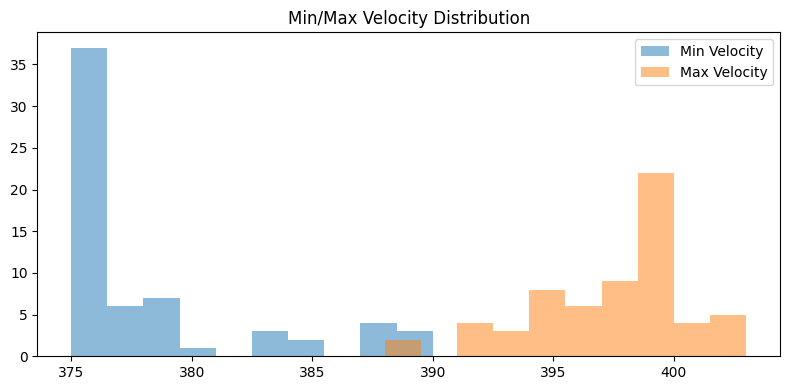

In [43]:
min_velocity = []
max_velocity = []

for stim, sessions in stim_sessions_extrema.items():
    for session, data in sessions.items():
        min_velocity.append(data['velocity'][0])
        max_velocity.append(data['velocity'][1])

plt.figure(figsize=(8, 4))
plt.hist(min_velocity, alpha=0.5, label='Min Velocity')
plt.hist(max_velocity, alpha=0.5, label='Max Velocity')
plt.legend()
plt.title('Min/Max Velocity Distribution')
plt.tight_layout()
plt.show()

In [37]:
stim_sessions_extrema[stim][session]['velocity']

(np.int64(375), np.int64(399))

Text(0.5, 1.0, 'histogram of winners to Covariance')

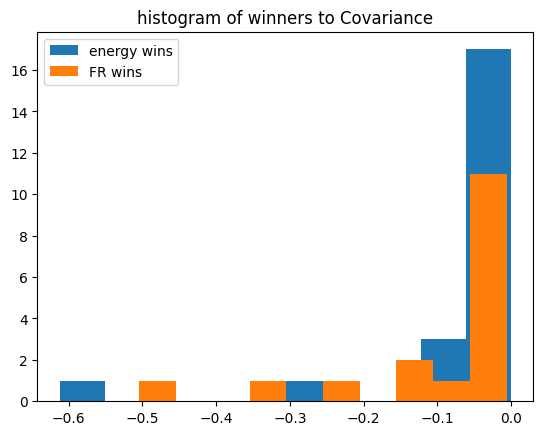

In [28]:
plt.hist(results['summary_df'][results['summary_df']['Winner'] == "energy"]['Covariance'], label="energy wins")
plt.hist(results['summary_df'][results['summary_df']['Winner'] != "energy"]['Covariance'], label="FR wins")
plt.legend()
plt.title("histogram of winners to Covariance")

In [33]:
print("energy winning: Covariance")
print(results['summary_df'][results['summary_df']['Winner'] == "energy"]['Covariance'].describe())

print("\n Firing rate winning: Covariance")
results['summary_df'][results['summary_df']['Winner'] != "energy"]['Covariance'].describe()

energy winning: Covariance
count    22.000000
mean     -0.057442
std       0.137044
min      -0.611555
25%      -0.023290
50%      -0.005779
75%      -0.001686
max      -0.000189
Name: Covariance, dtype: float64

 Firing rate winning: Covariance


count    17.000000
mean     -0.094448
std       0.139743
min      -0.504046
25%      -0.122202
50%      -0.031462
75%      -0.016470
max      -0.006002
Name: Covariance, dtype: float64

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from typing import Dict, List, Tuple, Optional
import warnings


def statistical_significance_tests(results: Dict, verbose: bool = True) -> Dict:
    """
    Perform statistical significance tests on within-session arbitration results.
    
    Tests performed:
    1. Binomial test - Are energy wins significantly more than chance (50%)?
    2. Paired t-test - Are energy distances significantly smaller than firing rate distances?
    3. Wilcoxon signed-rank test - Non-parametric alternative to paired t-test
    4. Effect size (Cohen's d) - Magnitude of the difference
    5. Bootstrap confidence intervals - Robustness check on win rate
    
    Parameters:
    -----------
    results : Dict
        Results dictionary from within_session_test, containing 'all_sessions' list
    verbose : bool
        Whether to print detailed results
        
    Returns:
    --------
    Dict containing all statistical test results
    """
    
    stats_results = {
        'by_stimulus': {},
        'overall': {}
    }
    
    if verbose:
        print("=" * 80)
        print("STATISTICAL SIGNIFICANCE TESTS")
        print("=" * 80)
    
    # Extract data from results
    all_sessions = results['all_sessions']
    
    # Overall data
    all_energy_dists = [s['energy_best_dist'] for s in all_sessions]
    all_firing_dists = [s['firing_best_dist'] for s in all_sessions]
    all_winners = [s['winner'] for s in all_sessions]
    
    # Count wins (excluding ties)
    energy_wins = sum(1 for w in all_winners if w == 'energy')
    firing_wins = sum(1 for w in all_winners if w == 'firing')
    ties = sum(1 for w in all_winners if w == 'tie')
    n_non_tie = energy_wins + firing_wins
    n_total = len(all_winners)
    
    # =========================================================================
    # OVERALL TESTS
    # =========================================================================
    
    if verbose:
        print(f"\n{'='*80}")
        print("OVERALL RESULTS (ALL STIMULI)")
        print(f"{'='*80}")
        print(f"\nSample size: {n_total} sessions ({n_non_tie} non-tie comparisons)")
        print(f"Energy wins: {energy_wins}, Firing wins: {firing_wins}, Ties: {ties}")
    
    overall_stats = _run_all_tests(
        energy_dists=all_energy_dists,
        firing_dists=all_firing_dists,
        energy_wins=energy_wins,
        n_non_tie=n_non_tie,
        n_total=n_total,
        verbose=verbose
    )
    stats_results['overall'] = overall_stats
    
    # =========================================================================
    # BY STIMULUS TESTS
    # =========================================================================
    
    # Group by stimulus
    stimuli = sorted(set(s['stimulus'] for s in all_sessions))
    
    for stim in stimuli:
        stim_sessions = [s for s in all_sessions if s['stimulus'] == stim]
        
        stim_energy_dists = [s['energy_best_dist'] for s in stim_sessions]
        stim_firing_dists = [s['firing_best_dist'] for s in stim_sessions]
        stim_winners = [s['winner'] for s in stim_sessions]
        
        stim_energy_wins = sum(1 for w in stim_winners if w == 'energy')
        stim_firing_wins = sum(1 for w in stim_winners if w == 'firing')
        stim_n_non_tie = stim_energy_wins + stim_firing_wins
        stim_n_total = len(stim_sessions)
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"STIMULUS {stim}")
            print(f"{'='*80}")
            print(f"\nSample size: {stim_n_total} sessions ({stim_n_non_tie} non-tie comparisons)")
            print(f"Energy wins: {stim_energy_wins}, Firing wins: {stim_firing_wins}")
        
        stim_stats = _run_all_tests(
            energy_dists=stim_energy_dists,
            firing_dists=stim_firing_dists,
            energy_wins=stim_energy_wins,
            n_non_tie=stim_n_non_tie,
            n_total=stim_n_total,
            verbose=verbose
        )
        stats_results['by_stimulus'][stim] = stim_stats
    
    # =========================================================================
    # SUMMARY TABLE
    # =========================================================================
    
    if verbose:
        print(f"\n{'='*80}")
        print("SUMMARY TABLE")
        print(f"{'='*80}")
        
        print(f"\n{'Test':<35} {'Overall':>12} {'Stim 0':>12} {'Stim 1':>12} {'Stim 2':>12}")
        print("-" * 85)
        
        # Binomial p-value
        row = f"{'Binomial test p-value':<35}"
        row += f" {stats_results['overall']['binomial_p']:>12.4f}"
        for stim in stimuli:
            row += f" {stats_results['by_stimulus'][stim]['binomial_p']:>12.4f}"
        print(row)
        
        # Paired t-test p-value
        row = f"{'Paired t-test p-value':<35}"
        row += f" {stats_results['overall']['ttest_p']:>12.4f}"
        for stim in stimuli:
            row += f" {stats_results['by_stimulus'][stim]['ttest_p']:>12.4f}"
        print(row)
        
        # Wilcoxon p-value
        row = f"{'Wilcoxon signed-rank p-value':<35}"
        row += f" {stats_results['overall']['wilcoxon_p']:>12.4f}"
        for stim in stimuli:
            row += f" {stats_results['by_stimulus'][stim]['wilcoxon_p']:>12.4f}"
        print(row)
        
        # Cohen's d
        row = f"{'Cohens d (effect size)':<35}"
        row += f" {stats_results['overall']['cohens_d']:>12.3f}"
        for stim in stimuli:
            row += f" {stats_results['by_stimulus'][stim]['cohens_d']:>12.3f}"
        print(row)
        
        # Win rate
        row = f"{'Energy win rate':<35}"
        row += f" {stats_results['overall']['win_rate']*100:>11.1f}%"
        for stim in stimuli:
            row += f" {stats_results['by_stimulus'][stim]['win_rate']*100:>11.1f}%"
        print(row)
        
        # Bootstrap CI
        row = f"{'Bootstrap 95% CI (win rate)':<35}"
        ci = stats_results['overall']['bootstrap_ci']
        row += f" [{ci[0]*100:.1f}-{ci[1]*100:.1f}%]".rjust(12)
        for stim in stimuli:
            ci = stats_results['by_stimulus'][stim]['bootstrap_ci']
            row += f" [{ci[0]*100:.1f}-{ci[1]*100:.1f}%]".rjust(12)
        print(row)
        
        print(f"\n{'='*80}")
        print("INTERPRETATION GUIDE")
        print(f"{'='*80}")
        print("""
p-value thresholds:
  p < 0.001  : Very strong evidence (***) 
  p < 0.01   : Strong evidence (**)
  p < 0.05   : Moderate evidence (*)
  p < 0.10   : Weak/marginal evidence (.)
  p >= 0.10  : Not significant

Cohen's d effect size:
  |d| < 0.2  : Negligible
  |d| 0.2-0.5: Small
  |d| 0.5-0.8: Medium
  |d| > 0.8  : Large

Bootstrap CI:
  If 95% CI excludes 50%, the win rate is significantly different from chance.
""")
        
        # Overall interpretation
        print(f"{'='*80}")
        print("OVERALL INTERPRETATION")
        print(f"{'='*80}")
        
        overall = stats_results['overall']
        
        print(f"\n1. BINOMIAL TEST (win counts)")
        if overall['binomial_p'] < 0.05:
            print(f"   ✓ SIGNIFICANT: Energy wins significantly more than chance (p = {overall['binomial_p']:.4f})")
        else:
            print(f"   ✗ NOT SIGNIFICANT: Energy win rate not significantly different from chance (p = {overall['binomial_p']:.4f})")
        
        print(f"\n2. PAIRED T-TEST (distances)")
        if overall['ttest_p'] < 0.05:
            print(f"   ✓ SIGNIFICANT: Energy distances significantly smaller than firing rate (p = {overall['ttest_p']:.4f})")
        else:
            print(f"   ✗ NOT SIGNIFICANT: Distance difference not statistically significant (p = {overall['ttest_p']:.4f})")
        
        print(f"\n3. WILCOXON TEST (non-parametric)")
        if overall['wilcoxon_p'] < 0.05:
            print(f"   ✓ SIGNIFICANT: Energy distances significantly smaller (p = {overall['wilcoxon_p']:.4f})")
        else:
            print(f"   ✗ NOT SIGNIFICANT: Distance difference not statistically significant (p = {overall['wilcoxon_p']:.4f})")
        
        print(f"\n4. EFFECT SIZE")
        d = overall['cohens_d']
        if abs(d) < 0.2:
            effect_desc = "negligible"
        elif abs(d) < 0.5:
            effect_desc = "small"
        elif abs(d) < 0.8:
            effect_desc = "medium"
        else:
            effect_desc = "large"
        print(f"   Cohen's d = {d:.3f} ({effect_desc} effect)")
        
        print(f"\n5. BOOTSTRAP CONFIDENCE INTERVAL")
        ci = overall['bootstrap_ci']
        if ci[0] > 0.5:
            print(f"   ✓ 95% CI [{ci[0]*100:.1f}%, {ci[1]*100:.1f}%] excludes 50% - significant")
        elif ci[1] < 0.5:
            print(f"   ✗ 95% CI [{ci[0]*100:.1f}%, {ci[1]*100:.1f}%] below 50% - firing rate wins")
        else:
            print(f"   ~ 95% CI [{ci[0]*100:.1f}%, {ci[1]*100:.1f}%] includes 50% - not significant")
    
    return stats_results


def _run_all_tests(energy_dists: List, firing_dists: List, 
                   energy_wins: int, n_non_tie: int, n_total: int,
                   verbose: bool = True) -> Dict:
    """Run all statistical tests on a set of data."""
    
    results = {}
    
    energy_dists = np.array(energy_dists)
    firing_dists = np.array(firing_dists)
    
    # -------------------------------------------------------------------------
    # 1. BINOMIAL TEST
    # -------------------------------------------------------------------------
    # H0: P(energy wins) = 0.5
    # H1: P(energy wins) > 0.5 (one-tailed)
    
    if n_non_tie > 0:
        # Two-tailed test
        binomial_result = stats.binomtest(energy_wins, n_non_tie, 0.5, alternative='two-sided')
        binomial_p = binomial_result.pvalue
        # One-tailed test (energy > chance)
        binomial_result_one = stats.binomtest(energy_wins, n_non_tie, 0.5, alternative='greater')
        binomial_p_one = binomial_result_one.pvalue
    else:
        binomial_p = 1.0
        binomial_p_one = 1.0
    
    results['binomial_p'] = binomial_p
    results['binomial_p_one_tailed'] = binomial_p_one
    results['win_rate'] = energy_wins / n_non_tie if n_non_tie > 0 else 0
    
    if verbose:
        print(f"\n--- 1. Binomial Test ---")
        print(f"   H0: P(energy wins) = 0.5")
        print(f"   Observed: {energy_wins}/{n_non_tie} = {results['win_rate']*100:.1f}%")
        print(f"   p-value (two-tailed): {binomial_p:.4f}")
        print(f"   p-value (one-tailed): {binomial_p_one:.4f}")
    
    # -------------------------------------------------------------------------
    # 2. PAIRED T-TEST
    # -------------------------------------------------------------------------
    # H0: mean(energy_dist) = mean(firing_dist)
    # H1: mean(energy_dist) < mean(firing_dist) (one-tailed)
    
    # Calculate difference: firing - energy (positive if energy is better)
    diff = firing_dists - energy_dists
    
    if len(diff) > 1 and np.std(diff) > 0:
        ttest_stat, ttest_p_two = stats.ttest_rel(firing_dists, energy_dists)
        # One-tailed: energy < firing
        ttest_p_one = ttest_p_two / 2 if ttest_stat > 0 else 1 - ttest_p_two / 2
    else:
        ttest_stat = 0
        ttest_p_two = 1.0
        ttest_p_one = 1.0
    
    results['ttest_stat'] = ttest_stat
    results['ttest_p'] = ttest_p_two
    results['ttest_p_one_tailed'] = ttest_p_one
    results['mean_diff'] = np.mean(diff)
    results['std_diff'] = np.std(diff)
    
    if verbose:
        print(f"\n--- 2. Paired T-Test ---")
        print(f"   H0: mean(energy_dist) = mean(firing_dist)")
        print(f"   Mean energy dist: {np.mean(energy_dists):.2f} ± {np.std(energy_dists):.2f}")
        print(f"   Mean firing dist: {np.mean(firing_dists):.2f} ± {np.std(firing_dists):.2f}")
        print(f"   Mean difference (firing - energy): {results['mean_diff']:.2f} ± {results['std_diff']:.2f}")
        print(f"   t-statistic: {ttest_stat:.3f}")
        print(f"   p-value (two-tailed): {ttest_p_two:.4f}")
        print(f"   p-value (one-tailed): {ttest_p_one:.4f}")
    
    # -------------------------------------------------------------------------
    # 3. WILCOXON SIGNED-RANK TEST
    # -------------------------------------------------------------------------
    # Non-parametric alternative to paired t-test
    
    # Remove zeros (ties in differences)
    diff_nonzero = diff[diff != 0]
    
    if len(diff_nonzero) > 10:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            wilcoxon_stat, wilcoxon_p = stats.wilcoxon(diff_nonzero, alternative='two-sided')
            _, wilcoxon_p_one = stats.wilcoxon(diff_nonzero, alternative='greater')
    else:
        wilcoxon_stat = 0
        wilcoxon_p = 1.0
        wilcoxon_p_one = 1.0
    
    results['wilcoxon_stat'] = wilcoxon_stat
    results['wilcoxon_p'] = wilcoxon_p
    results['wilcoxon_p_one_tailed'] = wilcoxon_p_one
    
    if verbose:
        print(f"\n--- 3. Wilcoxon Signed-Rank Test ---")
        print(f"   H0: Median difference = 0")
        print(f"   W-statistic: {wilcoxon_stat:.1f}")
        print(f"   p-value (two-tailed): {wilcoxon_p:.4f}")
        print(f"   p-value (one-tailed): {wilcoxon_p_one:.4f}")
    
    # -------------------------------------------------------------------------
    # 4. EFFECT SIZE (Cohen's d)
    # -------------------------------------------------------------------------
    # For paired samples: d = mean(diff) / std(diff)
    
    if np.std(diff) > 0:
        cohens_d = np.mean(diff) / np.std(diff)
    else:
        cohens_d = 0
    
    results['cohens_d'] = cohens_d
    
    if verbose:
        print(f"\n--- 4. Effect Size (Cohen's d) ---")
        print(f"   d = {cohens_d:.3f}")
        if abs(cohens_d) < 0.2:
            print(f"   Interpretation: Negligible effect")
        elif abs(cohens_d) < 0.5:
            print(f"   Interpretation: Small effect")
        elif abs(cohens_d) < 0.8:
            print(f"   Interpretation: Medium effect")
        else:
            print(f"   Interpretation: Large effect")
    
    # -------------------------------------------------------------------------
    # 5. BOOTSTRAP CONFIDENCE INTERVAL
    # -------------------------------------------------------------------------
    # Bootstrap the win rate to get confidence interval
    
    winners_binary = [1 if w == 'energy' else 0 for w in 
                      ['energy'] * energy_wins + ['firing'] * (n_non_tie - energy_wins)]
    
    if len(winners_binary) > 0:
        bootstrap_ci = _bootstrap_ci(winners_binary, n_bootstrap=10000)
    else:
        bootstrap_ci = (0, 0)
    
    results['bootstrap_ci'] = bootstrap_ci
    
    if verbose:
        print(f"\n--- 5. Bootstrap 95% Confidence Interval ---")
        print(f"   Win rate: {results['win_rate']*100:.1f}%")
        print(f"   95% CI: [{bootstrap_ci[0]*100:.1f}%, {bootstrap_ci[1]*100:.1f}%]")
        if bootstrap_ci[0] > 0.5:
            print(f"   ✓ CI excludes 50% - significantly better than chance")
        elif bootstrap_ci[1] < 0.5:
            print(f"   ✗ CI below 50% - significantly worse than chance")
        else:
            print(f"   ~ CI includes 50% - not significantly different from chance")
    
    return results


def _bootstrap_ci(data: List, n_bootstrap: int = 10000, ci: float = 0.95) -> Tuple[float, float]:
    """Calculate bootstrap confidence interval for the mean."""
    
    data = np.array(data)
    n = len(data)
    
    if n == 0:
        return (0, 0)
    
    # Bootstrap resampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        resample = np.random.choice(data, size=n, replace=True)
        bootstrap_means.append(np.mean(resample))
    
    # Calculate percentiles
    lower = (1 - ci) / 2
    upper = 1 - lower
    
    ci_lower = np.percentile(bootstrap_means, lower * 100)
    ci_upper = np.percentile(bootstrap_means, upper * 100)
    
    return (ci_lower, ci_upper)


def create_significance_summary_table(stats_results: Dict) -> pd.DataFrame:
    """
    Create a publication-ready summary table of statistical results.
    
    Parameters:
    -----------
    stats_results : Dict
        Results from statistical_significance_tests
        
    Returns:
    --------
    pd.DataFrame
        Summary table suitable for publication
    """
    
    rows = []
    
    # Add overall row
    overall = stats_results['overall']
    rows.append({
        'Condition': 'Overall',
        'N': int(overall['win_rate'] * 100 / overall['win_rate']) if overall['win_rate'] > 0 else 0,  # hack to get n
        'Energy Win Rate': f"{overall['win_rate']*100:.1f}%",
        'Mean Diff (FR-E)': f"{overall['mean_diff']:.2f}",
        'Binomial p': f"{overall['binomial_p']:.4f}",
        'Paired t p': f"{overall['ttest_p']:.4f}",
        'Wilcoxon p': f"{overall['wilcoxon_p']:.4f}",
        "Cohen's d": f"{overall['cohens_d']:.3f}",
        '95% CI': f"[{overall['bootstrap_ci'][0]*100:.1f}%, {overall['bootstrap_ci'][1]*100:.1f}%]"
    })
    
    # Add stimulus rows
    for stim in sorted(stats_results['by_stimulus'].keys()):
        stim_data = stats_results['by_stimulus'][stim]
        rows.append({
            'Condition': f'Stimulus {stim}',
            'N': '',
            'Energy Win Rate': f"{stim_data['win_rate']*100:.1f}%",
            'Mean Diff (FR-E)': f"{stim_data['mean_diff']:.2f}",
            'Binomial p': f"{stim_data['binomial_p']:.4f}",
            'Paired t p': f"{stim_data['ttest_p']:.4f}",
            'Wilcoxon p': f"{stim_data['wilcoxon_p']:.4f}",
            "Cohen's d": f"{stim_data['cohens_d']:.3f}",
            '95% CI': f"[{stim_data['bootstrap_ci'][0]*100:.1f}%, {stim_data['bootstrap_ci'][1]*100:.1f}%]"
        })
    
    return pd.DataFrame(rows)



summary_df = create_significance_summary_table(results)
print(summary_df.to_string(index=False))

# Test if energy wins during low covariance

In [109]:
from scipy import stats

cov_when_0 = abs(results['summary_df']['Covariance'][results['summary_df']['Winner'] != "energy"])
cov_when_1 = abs(results['summary_df']['Covariance'][results['summary_df']['Winner'] == "energy"])
results['summary_df']['Covariance'] = abs(results['summary_df']['Covariance'])

# Welch's t-test (doesn't assume equal variances)
t_stat, p_value = stats.ttest_ind(cov_when_1, cov_when_0, alternative='less')
print(f"t-stat: {t_stat}, p_value: {p_value}")

t-stat: -0.8291130977560462, p_value: 0.20617873618450688


In [102]:
from sklearn.linear_model import LogisticRegression


np.float64(nan)

In [118]:
results['summary_df'].loc[results['summary_df']['Winner'] == "energy", 'Winner'] = 1
results['summary_df'].loc[results['summary_df']['Winner'] != 1, 'Winner'] = 0

In [126]:
!pip3 install scikit-learn
!pip3 install statsmodels

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 117.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [124]:
from sklearn.linear_model import LogisticRegression

X = results['summary_df']['Covariance'].to_numpy().reshape(-1, 1)
y = results['summary_df']['Winner'].to_numpy().astype(int)

model = LogisticRegression()
model.fit(X, y)

print(f"Coefficient: {model.coef_[0][0]:.4f}")

Coefficient: 0.3012


In [127]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X)  # Adds intercept
model = sm.Logit(y, X_with_const)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.675802
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   39
Model:                          Logit   Df Residuals:                       37
Method:                           MLE   Df Model:                            1
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                 0.01329
Time:                        15:46:19   Log-Likelihood:                -26.356
converged:                       True   LL-Null:                       -26.711
Covariance Type:            nonrobust   LLR p-value:                    0.3994
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4075      0.371      1.097      0.272      -0.320       1.135
x1             2.0287      2.

In [40]:
csv_df = []

for stim in stim_sessions_extrema.keys():
    for session in stim_sessions_extrema[stim].keys():
        
        
        csv_df += [
            {
                'stim':stim,
                'session': session,
                'velocity_min':stim_sessions_extrema[stim][session]['velocity'][0],
                'velocity_max':stim_sessions_extrema[stim][session]['velocity'][1],
                'firing_rate_min':stim_sessions_extrema[stim][session]['firing_rate'][0],
                'firing_rate_min':stim_sessions_extrema[stim][session]['firing_rate'][1],
                'energy_min':stim_sessions_extrema[stim][session]['energy'][0],
                'energy_max':stim_sessions_extrema[stim][session]['energy'][1],
                
            }
        ]

In [43]:
pd.DataFrame(csv_df).to_csv("sessions_extrema_summary.csv")